# Obesity data analysis

### 1. Importing and loading data set from csv file

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("data/obesity_data.csv")

# Display first rows
df.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### 2. Basic data analysis EDA

Missing values check (for categorical and numeric)

In [103]:
nulls = df.isnull().sum()
display(nulls)

nulls.to_csv(f"figures/tables/null_values.csv", index=True)

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

#### 2.1 Numerical features:

In [4]:
numeric = df.describe(percentiles=[.05, .95])
display(numeric)

numeric.to_csv(f"figures/tables/numeric.csv", index=True)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
5%,17.891428,1.548291,48.500000,1.523214,1.000000,1.000000,0.000000,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
95%,38.098070,1.850000,131.916152,3.000000,3.750881,3.000000,2.677133,2.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


#### 2.2 Categorical features analysis:

unique classes in each column:

In [4]:
unique = df.select_dtypes(include=['object']).nunique()
display(unique)

unique.to_csv(f"figures/tables/categoric_unique_classes.csv", index=True)

Gender                            2
family_history_with_overweight    2
FAVC                              2
CAEC                              4
SMOKE                             2
SCC                               2
CALC                              4
MTRANS                            5
NObeyesdad                        7
dtype: int64

proportion of the classes (in %)

In [4]:
# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Compute proportions for each category and save as CSV
for col in categorical_cols:

    proportions = pd.DataFrame(df[col].value_counts(normalize=True) * 100).rename(columns={col: "Percentage"})
    display(proportions)
    
    proportions.to_csv(f"figures/tables/proportions/{col}.csv", index=True)  # Save file with the column name
    


,proportion
Gender,
Male,50.592136
Female,49.407864


,proportion
family_history_with_overweight,
yes,81.762198
no,18.237802


,proportion
FAVC,
yes,88.394126
no,11.605874


,proportion
CAEC,
Sometimes,83.609664
Frequently,11.463761
Always,2.510658
no,2.415917


,proportion
SMOKE,
no,97.91568
yes,2.08432


,proportion
SCC,
no,95.452392
yes,4.547608


,proportion
CALC,
Sometimes,66.366651
no,30.270014
Frequently,3.315964
Always,0.047371


,proportion
MTRANS,
Public_Transportation,74.846045
Automobile,21.648508
Walking,2.652771
Motorbike,0.521080
Bike,0.331596


,proportion
NObeyesdad,
Obesity_Type_I,16.627191
Obesity_Type_III,15.348176
Obesity_Type_II,14.069162
Overweight_Level_I,13.737565
Overweight_Level_II,13.737565
Normal_Weight,13.595452
Insufficient_Weight,12.884889


Visualization of proportion of each class for categorical features (for easier and faster analysis)

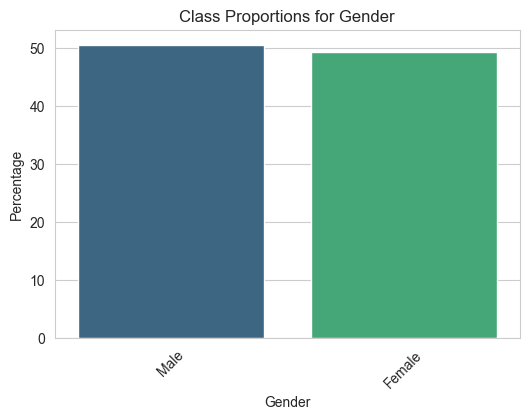

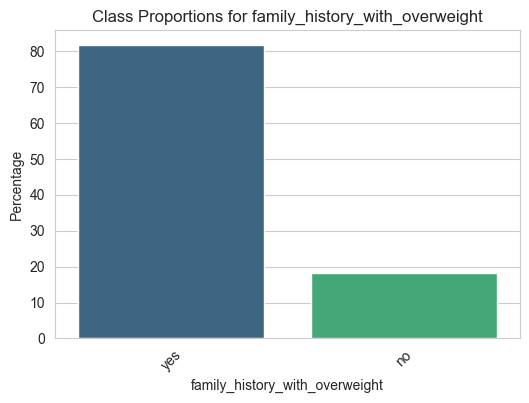

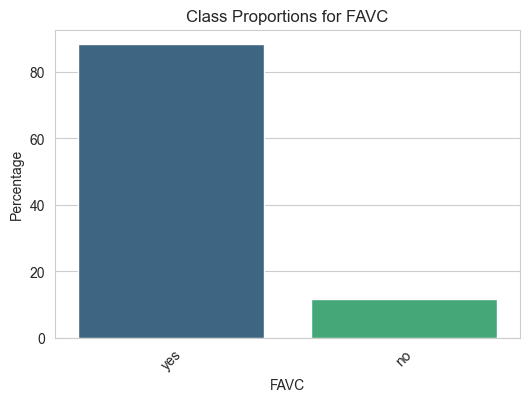

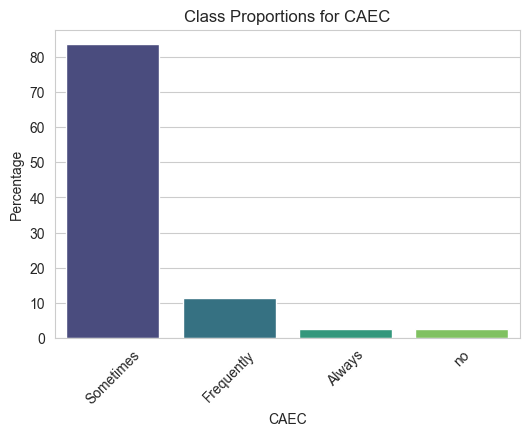

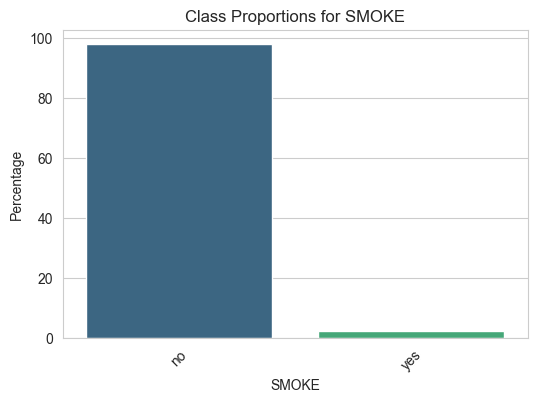

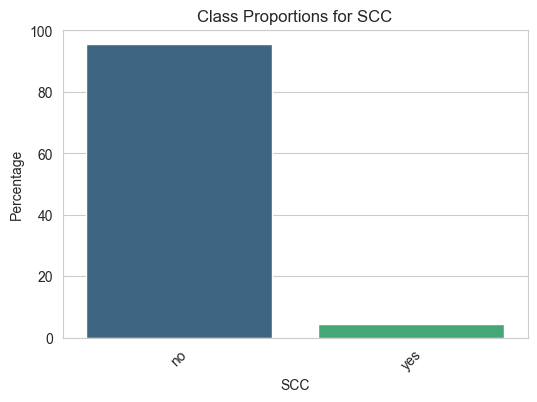

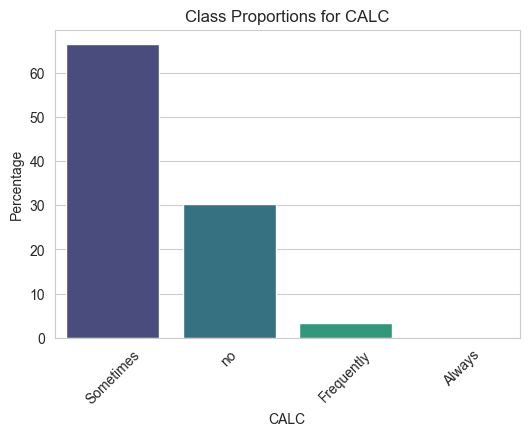

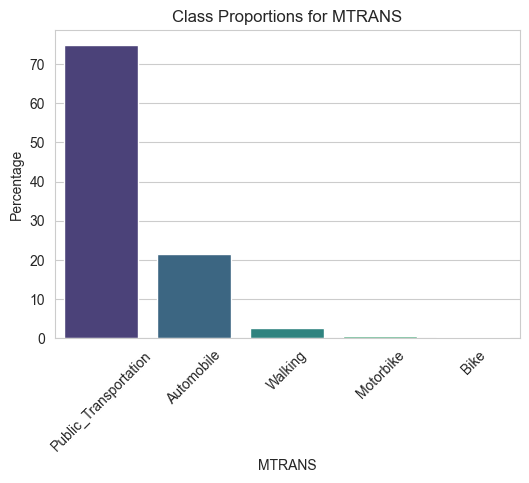

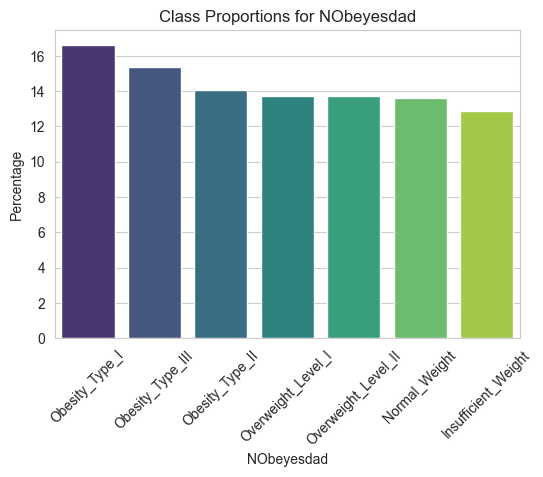

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.barplot(x=df[col].value_counts().index, 
                y=df[col].value_counts(normalize=True) * 100, 
                hue=df[col].value_counts().index, 
                legend=False,  # Hide legend since we already have x labels
                palette="viridis")
    plt.title(f"Class Proportions for {col}")
    plt.ylabel("Percentage")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.savefig(f"figures/proportion/{col}.png")
    plt.show()



### 3. Categoric data encoding

As we have a lot of categoric columns with just 2 classes we can encode them as 0 and 1 for better analysis 

In [87]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['family_history_with_overweight'] = df['family_history_with_overweight'].map({'yes': 1, 'no': 0})
df['FAVC'] = df['FAVC'].map({'yes': 1, 'no': 0})
df['SMOKE'] = df['SMOKE'].map({'yes': 1, 'no': 0})
df['SCC'] = df['SCC'].map({'yes': 1, 'no': 0})



Columns with more classes we can also try to encode to numeric like that

In [5]:
desired_order_obesity = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

desired_order_frequency = [
    "no",
    "Sometimes",
    "Frequently",
    "Always"
]


# Encode 'NObeyesdad' using pandas Categorical
df["Obesity_Encoded"] = pd.Categorical(df["NObeyesdad"], categories=desired_order_obesity, ordered=True).codes
df["CALC"] = pd.Categorical(df["CALC"], categories=desired_order_frequency, ordered=True).codes
df["CAEC"] = pd.Categorical(df["CAEC"], categories=desired_order_frequency, ordered=True).codes

Now we can use seaborn tools etc. on more features as most of them work only on numeric data

### 4. Data visualization

Importing necessary libraries

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

#### 4.1 **Boxplots**

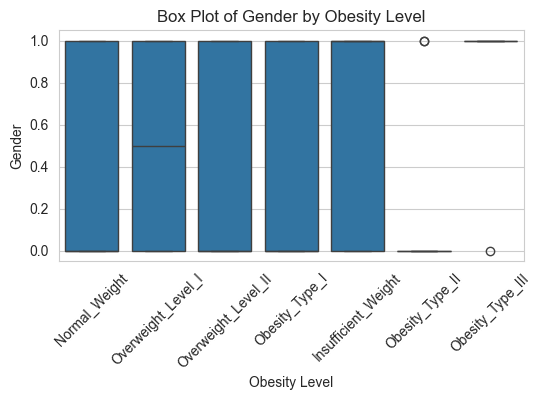

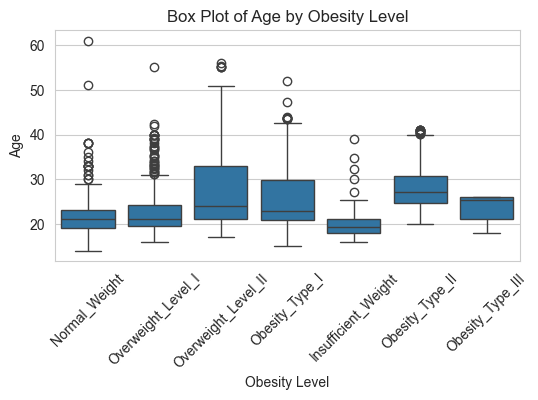

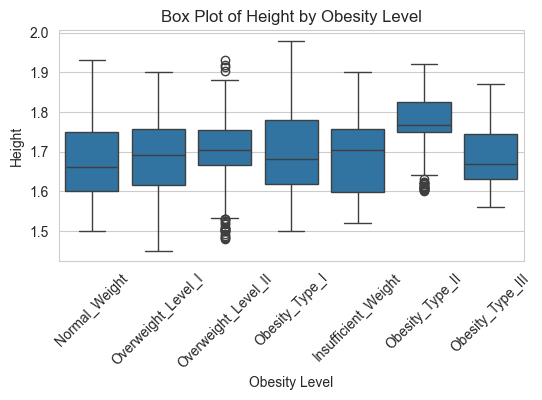

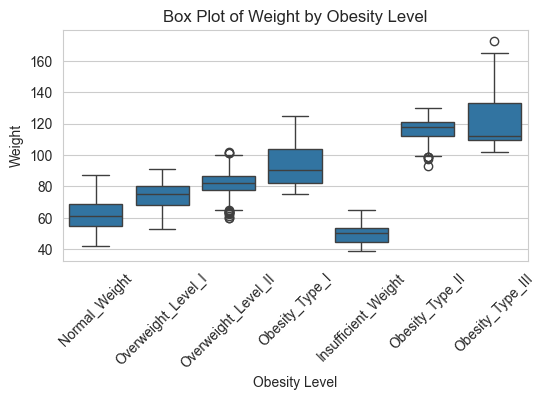

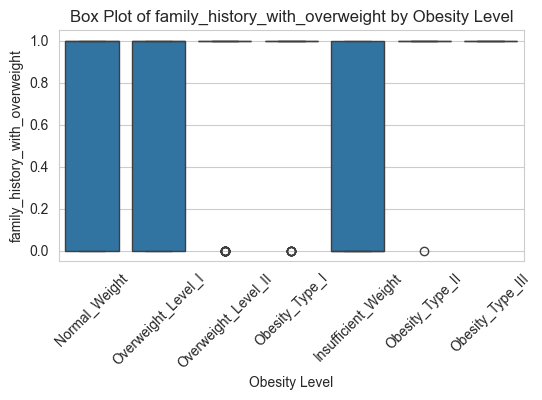

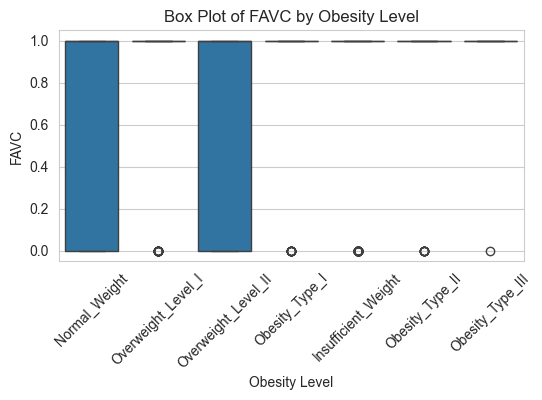

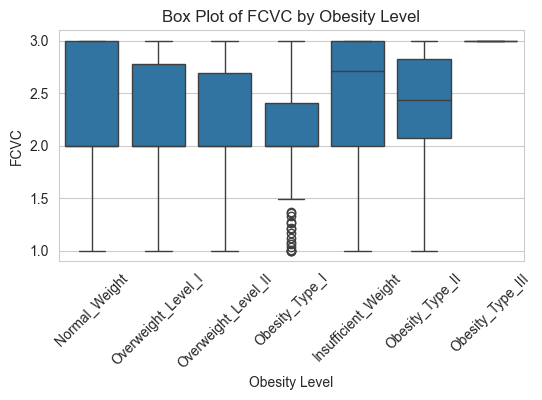

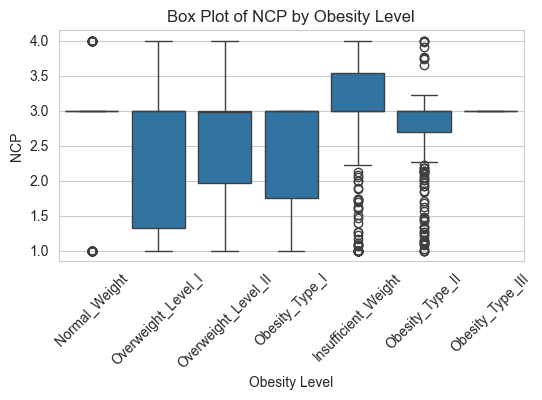

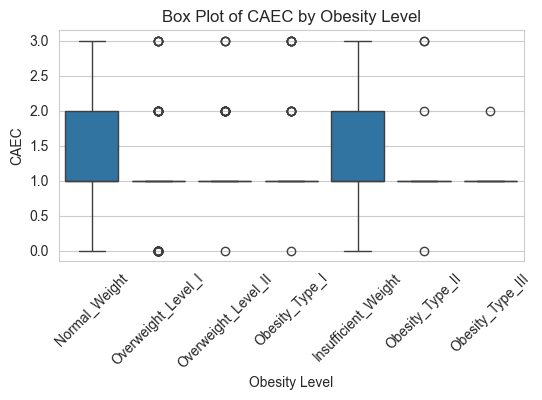

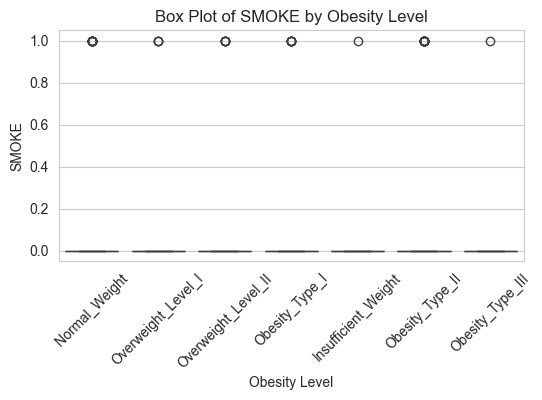

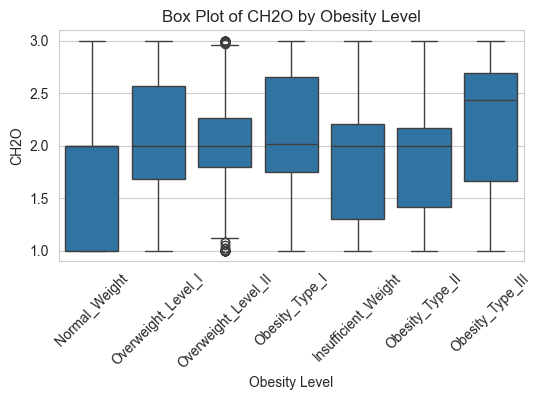

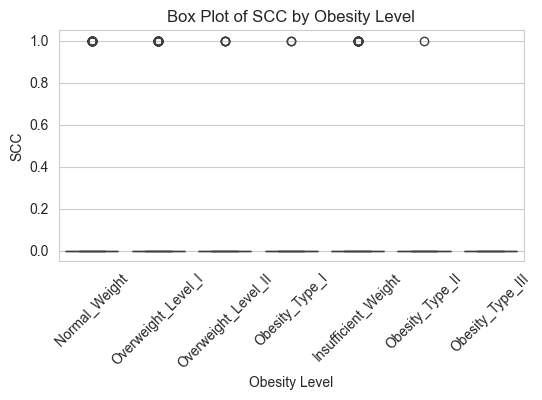

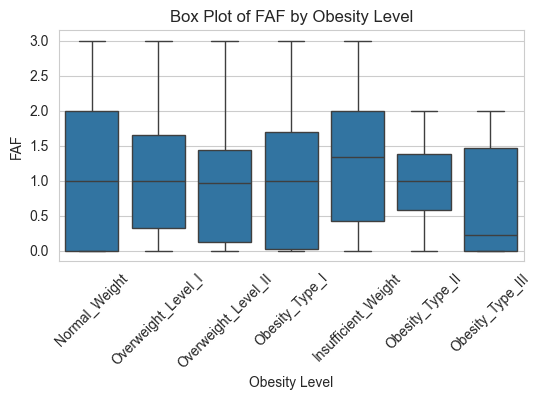

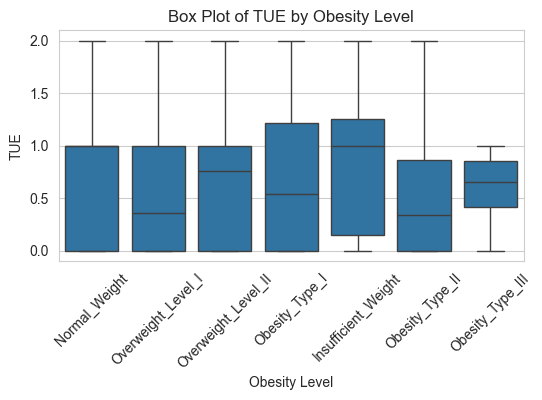

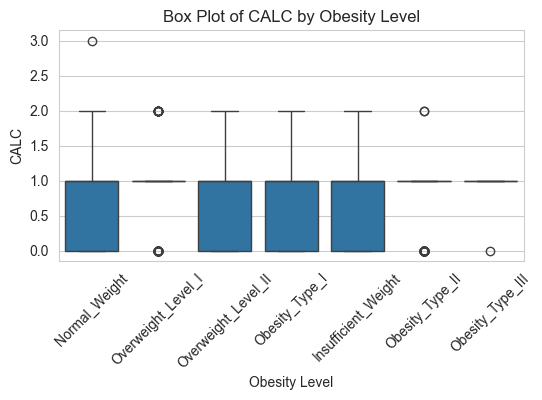

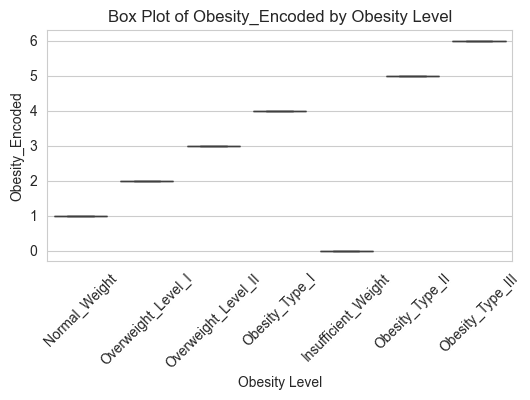

In [44]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Create box plots for each numeric column grouped by obesity level
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df["NObeyesdad"], y=df[col], data=df)
    plt.title(f"Box Plot of {col} by Obesity Level")
    plt.xticks(rotation=45)  # Rotate labels for better readability
    plt.xlabel("Obesity Level")
    plt.ylabel(col)
    plt.savefig(f"figures/boxplots/{col}.png")
    plt.show()

#### 4.2 **Violinplots**

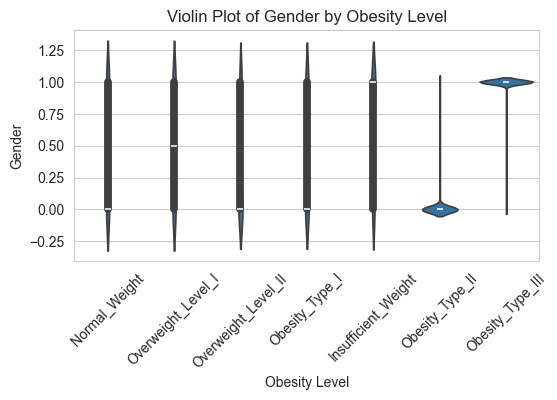

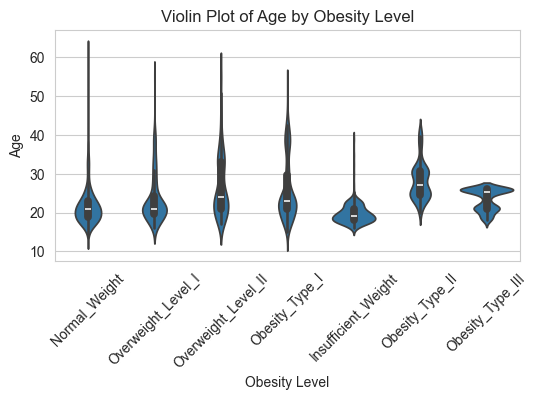

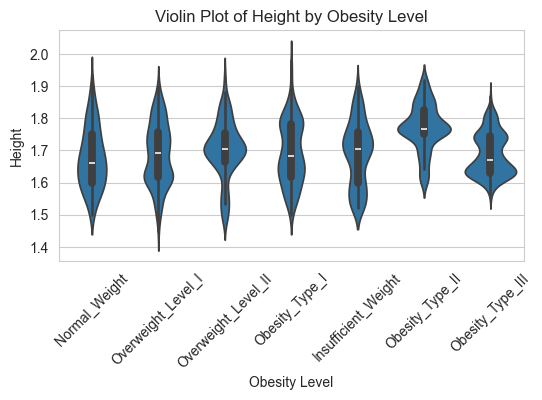

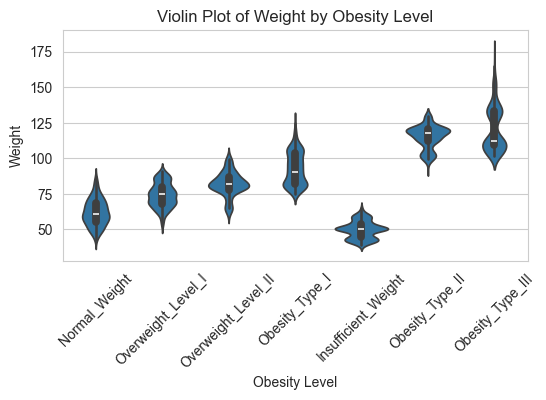

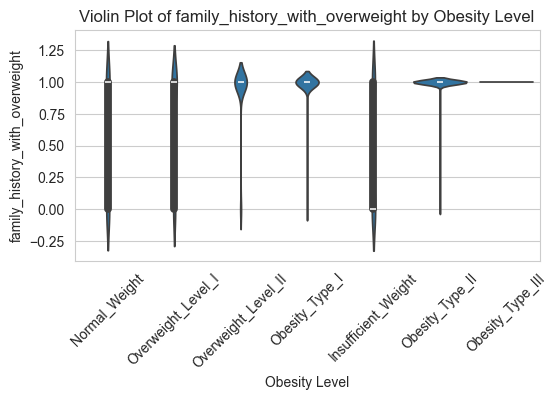

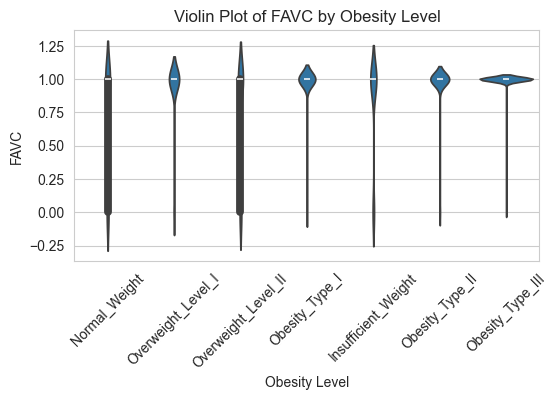

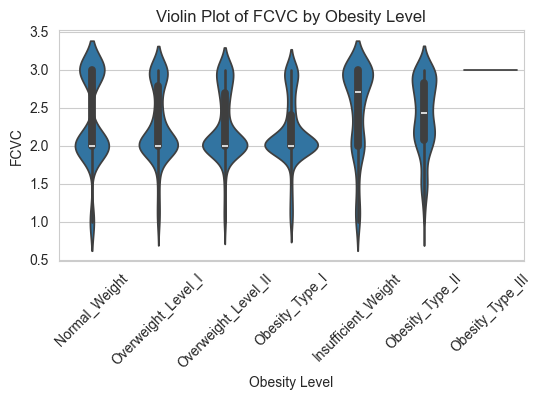

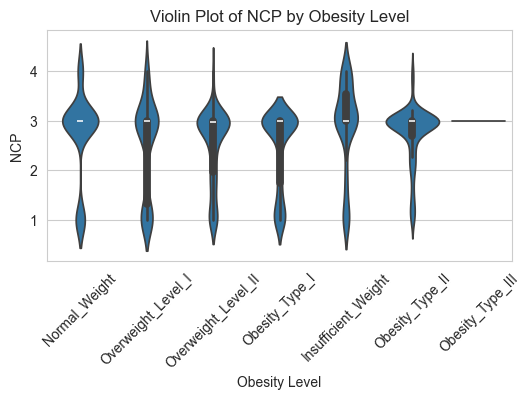

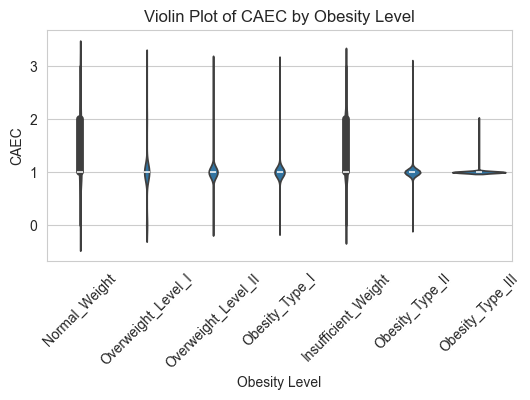

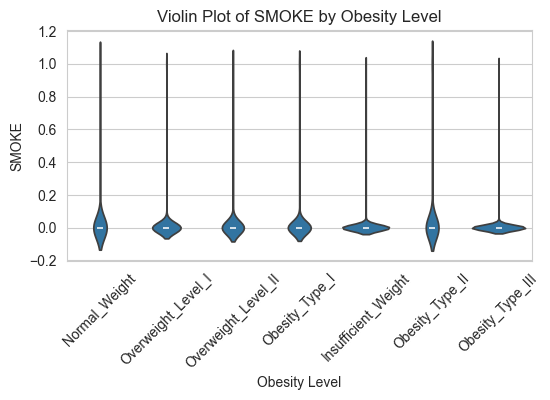

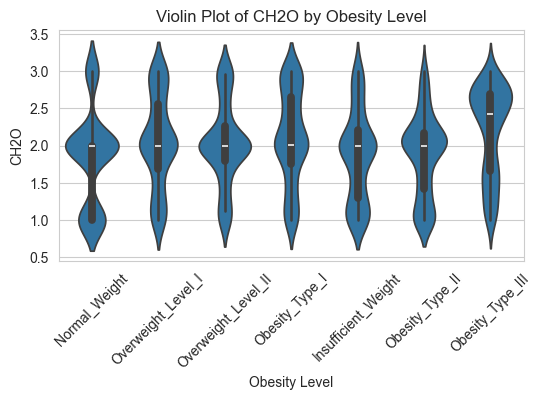

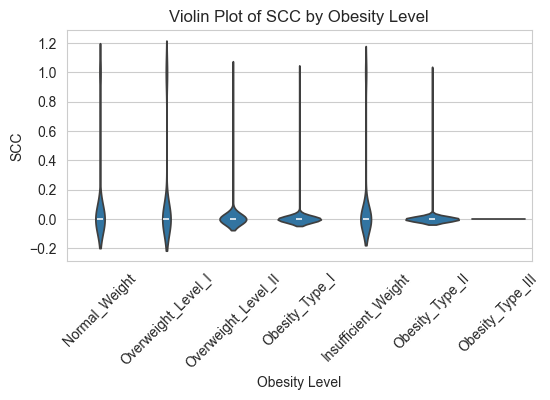

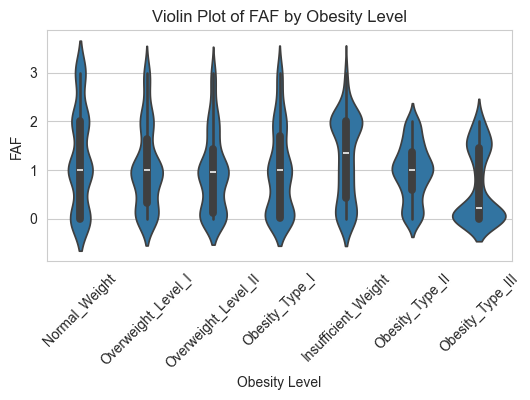

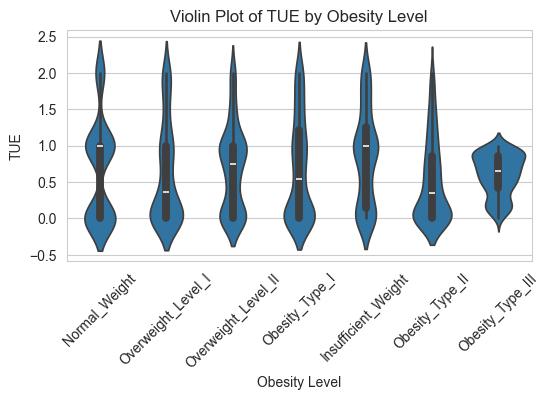

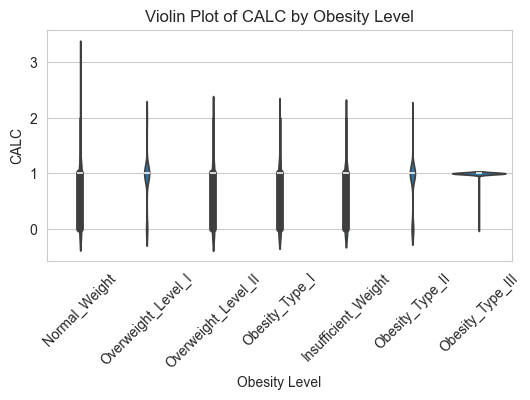

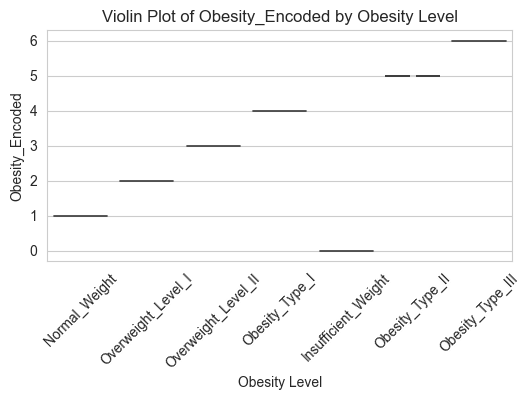

In [45]:
# Create violin plots for each numeric column grouped by obesity level
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.violinplot(x=df["NObeyesdad"], y=df[col], data=df)
    plt.title(f"Violin Plot of {col} by Obesity Level")
    plt.xticks(rotation=45)  # Rotate labels for better readability
    plt.xlabel("Obesity Level")
    plt.ylabel(col)
    plt.savefig(f"figures/violinplots/{col}.png")
    plt.show()

#### 4.3 **Error bars**

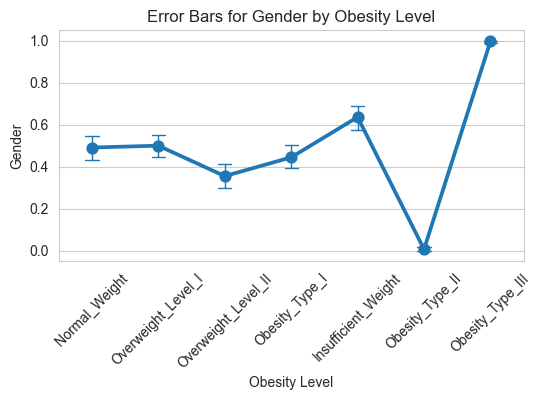

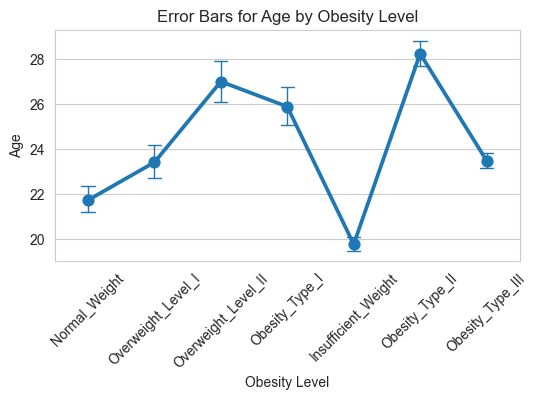

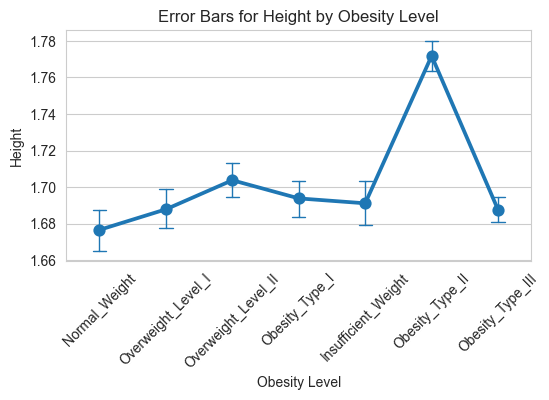

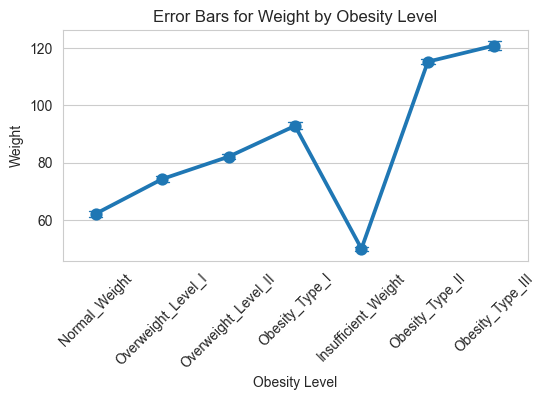

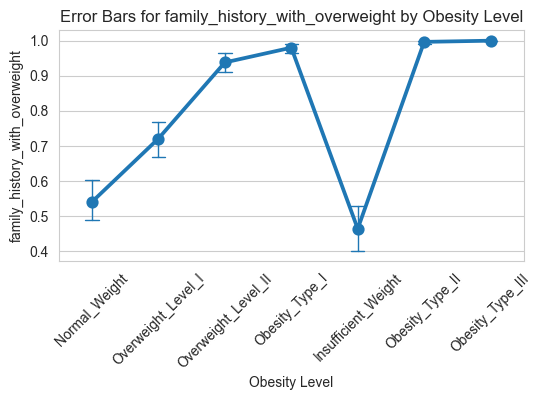

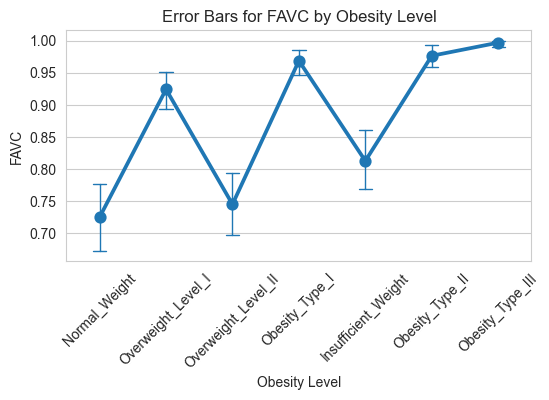

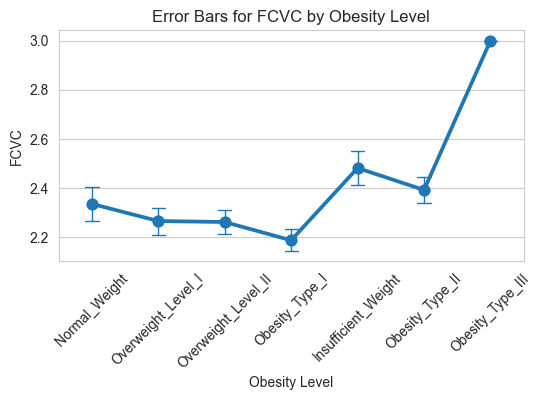

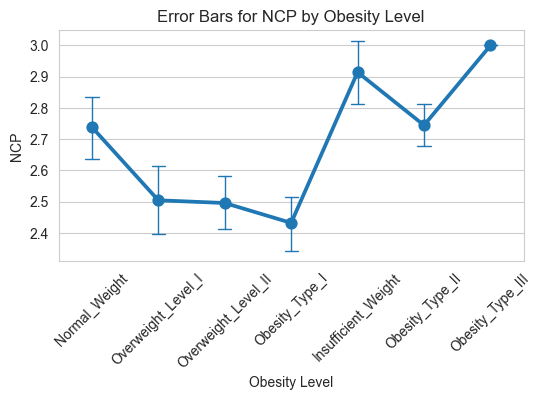

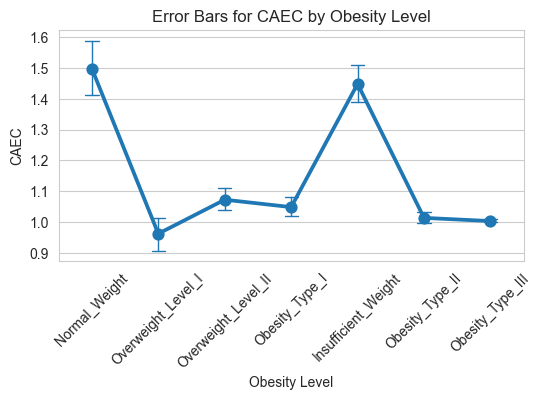

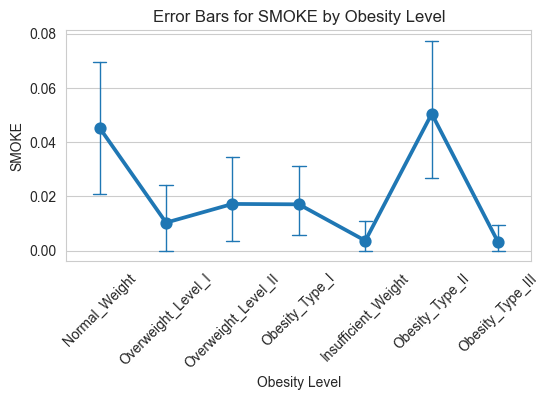

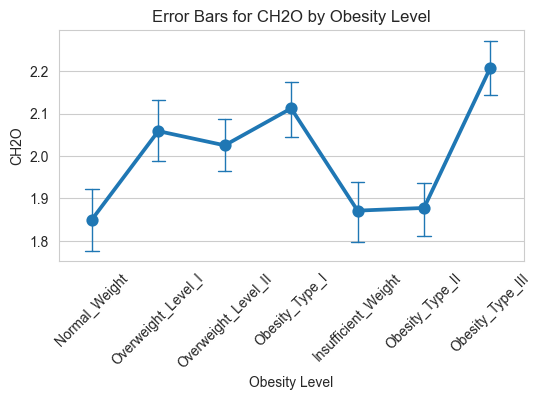

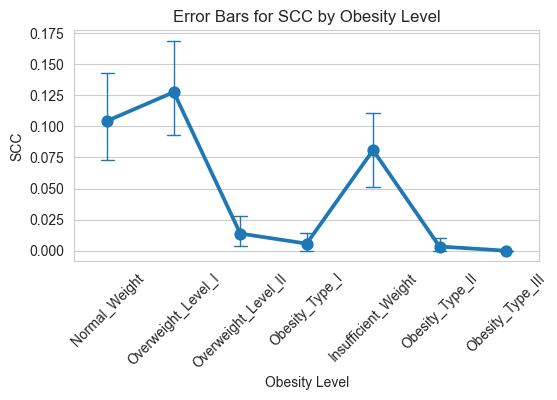

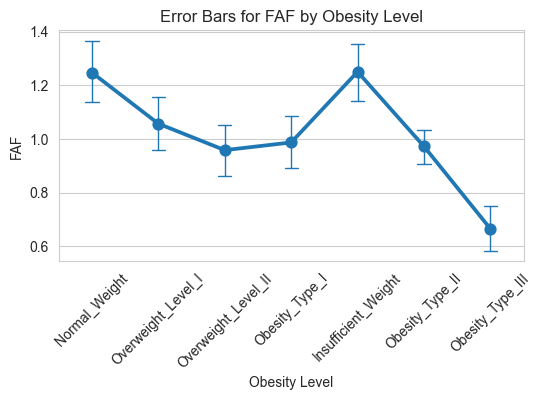

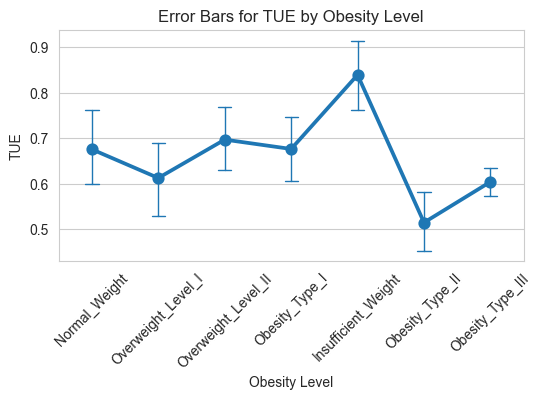

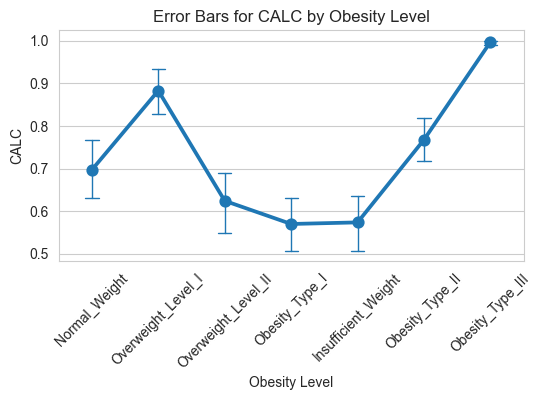

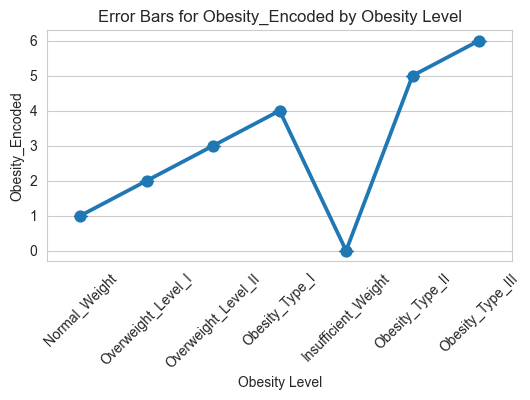

In [46]:
# Create error bar plots for each numeric column grouped by obesity level
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.pointplot(
        x=df["NObeyesdad"], y=df[col], data=df, 
        errorbar=("ci", 95),  # 0.95 confidence interval
        capsize=0.2, 
        err_kws={"linewidth": 1} 
    )
    plt.title(f"Error Bars for {col} by Obesity Level")
    plt.xticks(rotation=45)  # Rotate labels for better readability
    plt.xlabel("Obesity Level")
    plt.ylabel(col)
    plt.savefig(f"figures/errorbars/{col}.png")
    plt.show()

#### 4.4 **Histograms**

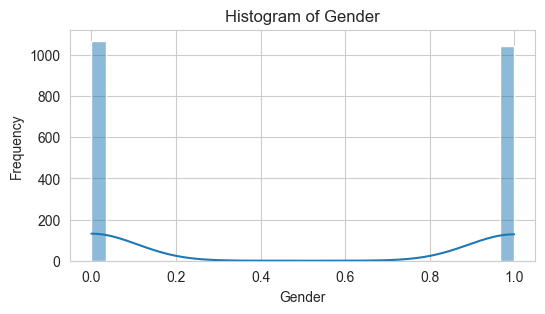

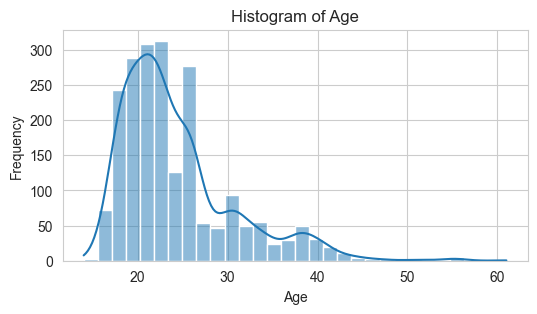

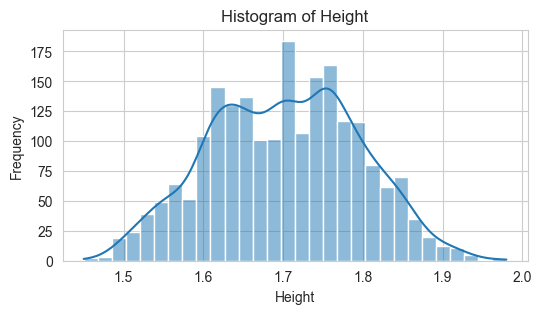

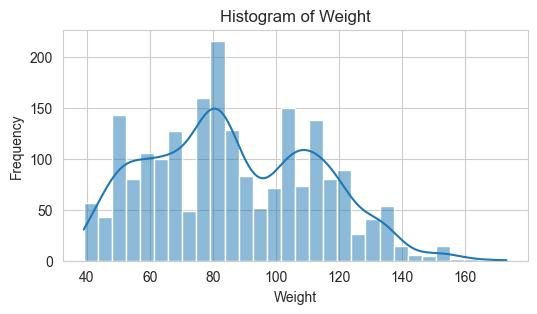

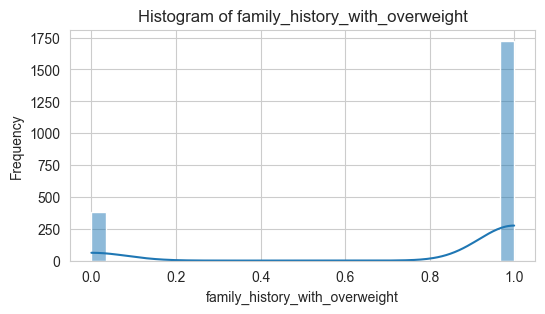

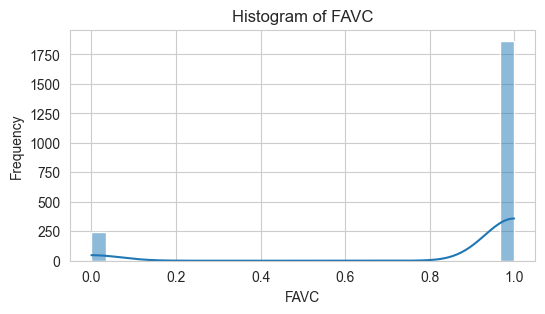

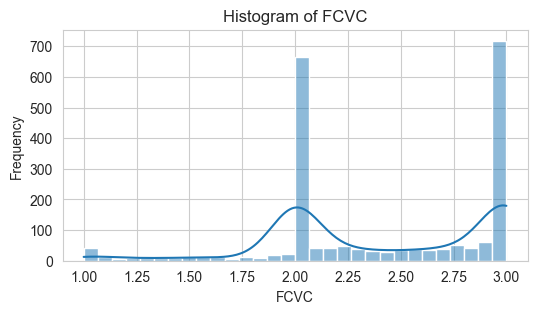

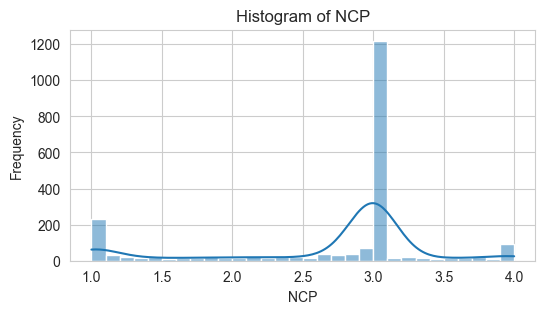

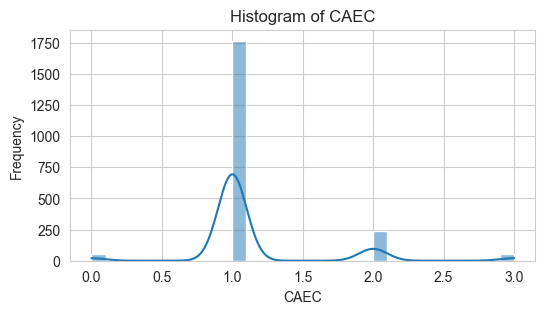

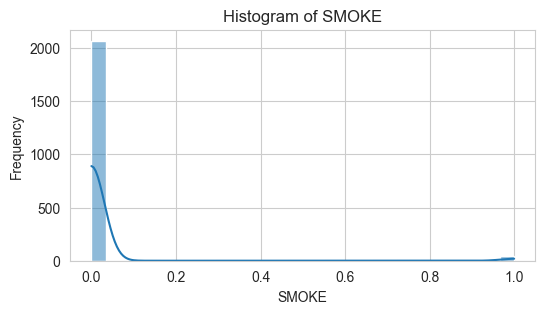

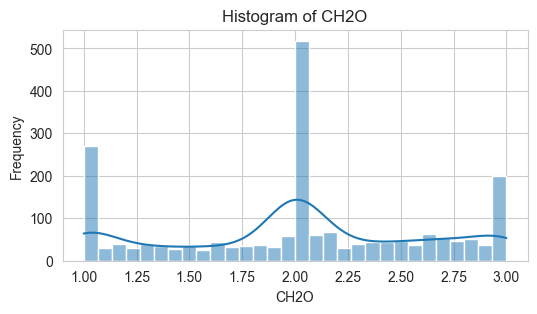

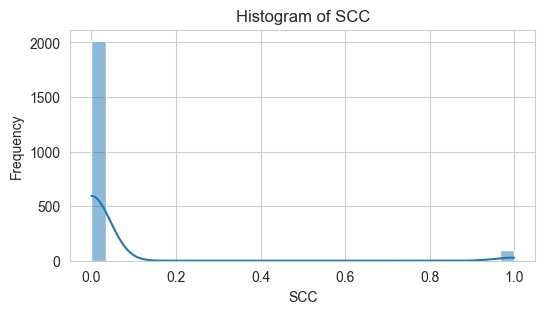

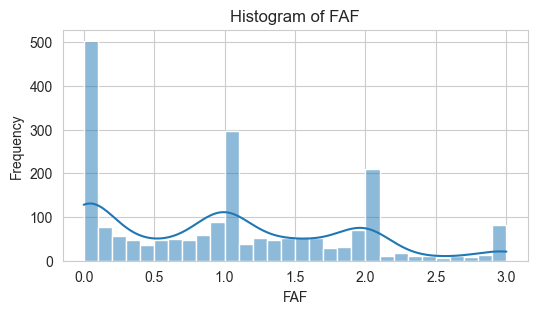

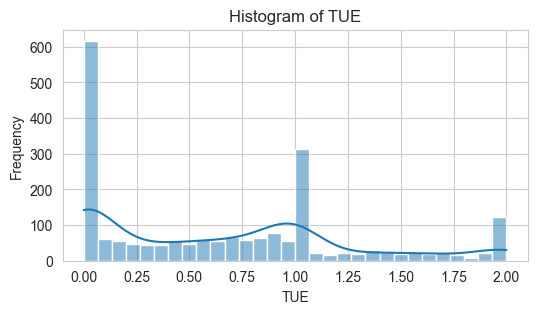

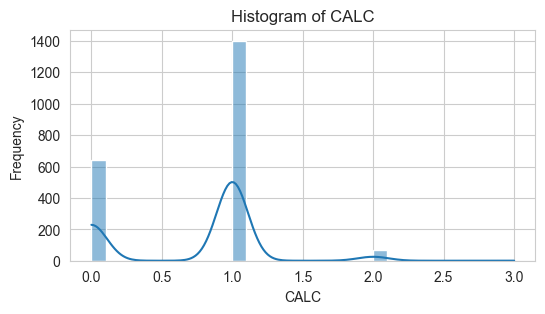

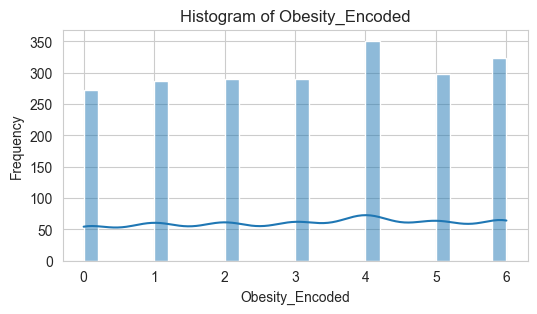

In [47]:
# Create histograms for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], bins=30, kde=True)  # Histogram with KDE (density curve)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.savefig(f"figures/histograms/{col}.png")
    plt.show()

#### 4.5 **Conditional histograms**

for each numerical column by obesity level

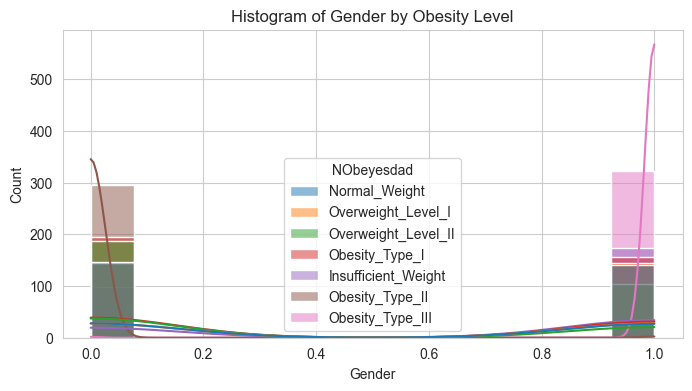

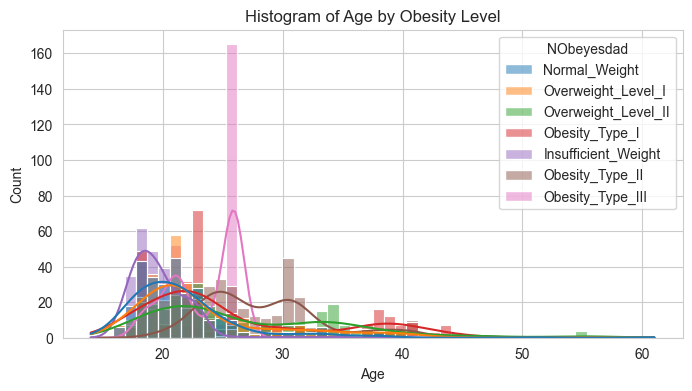

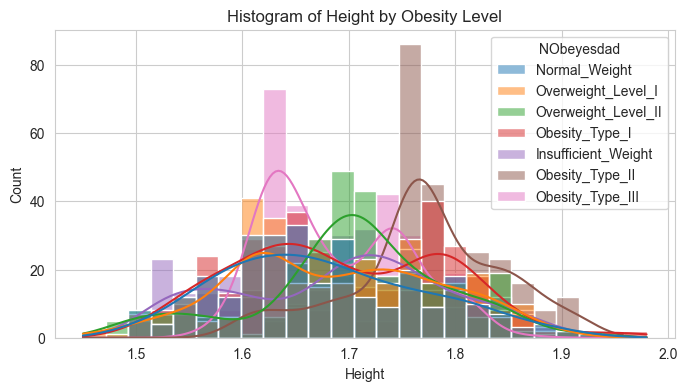

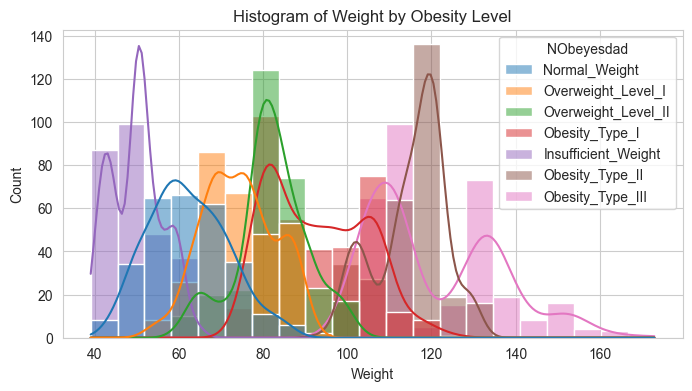

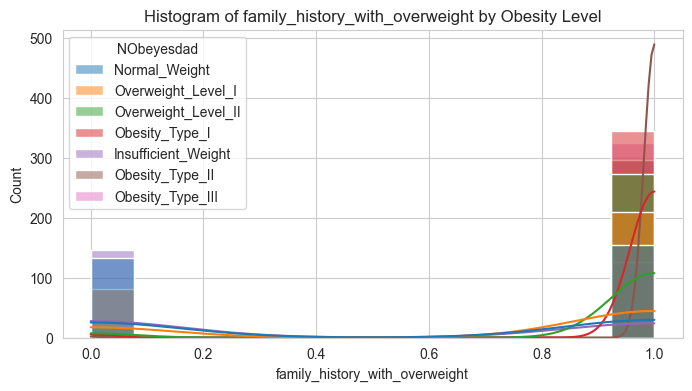

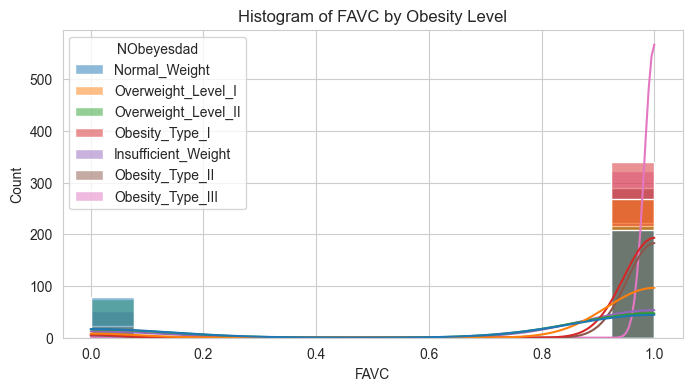

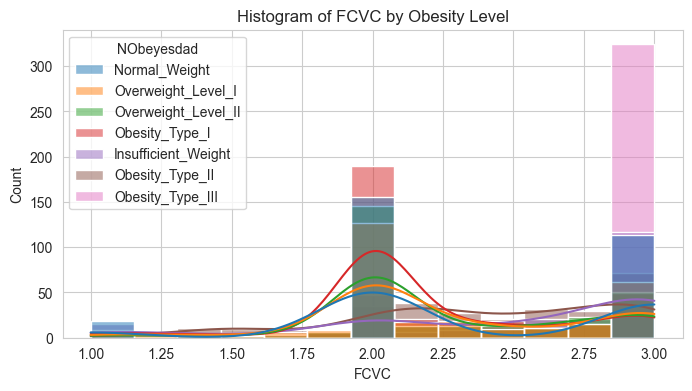

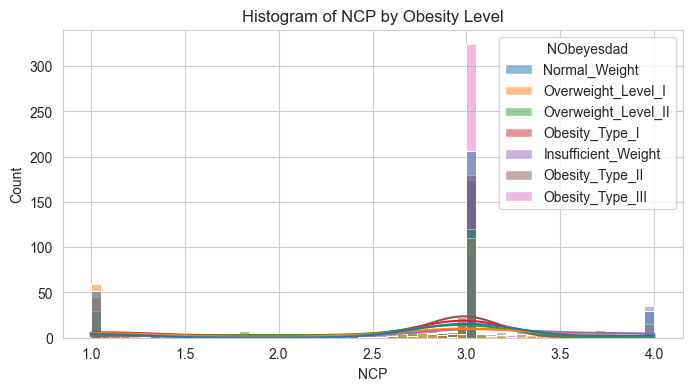

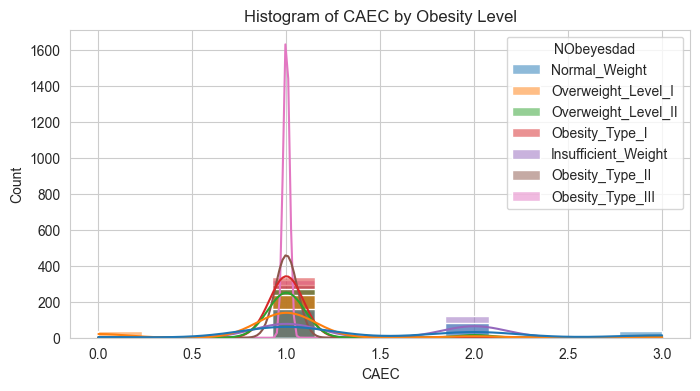

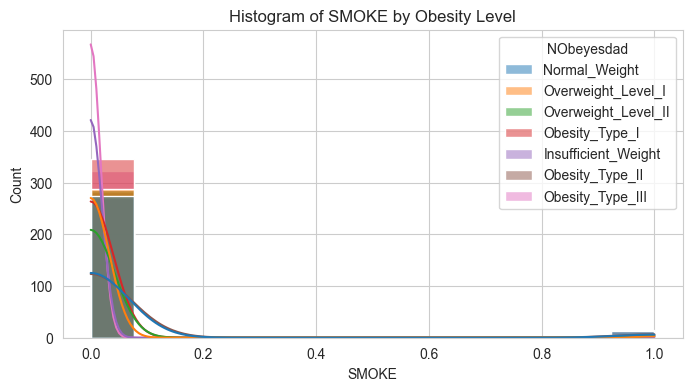

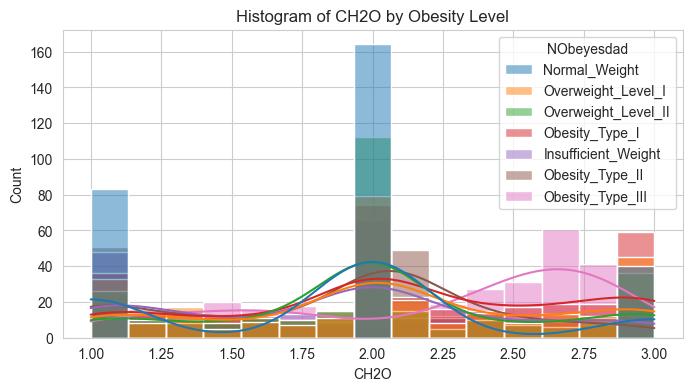

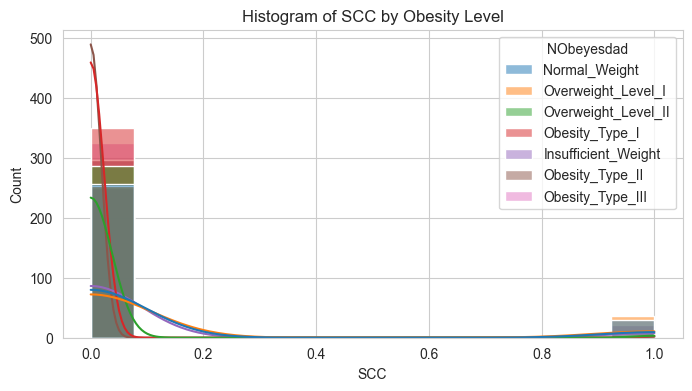

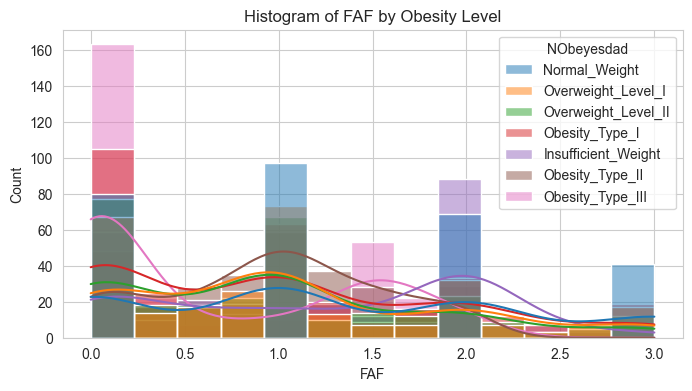

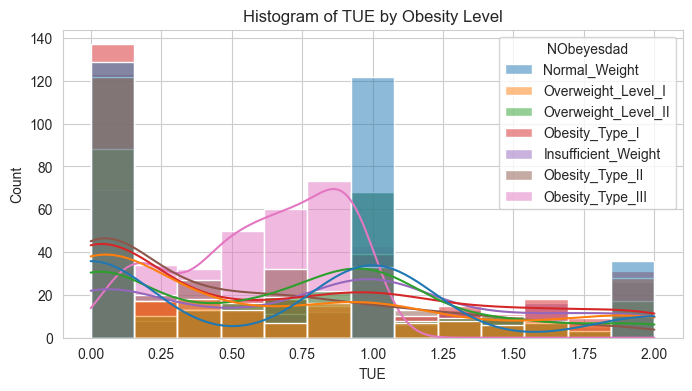

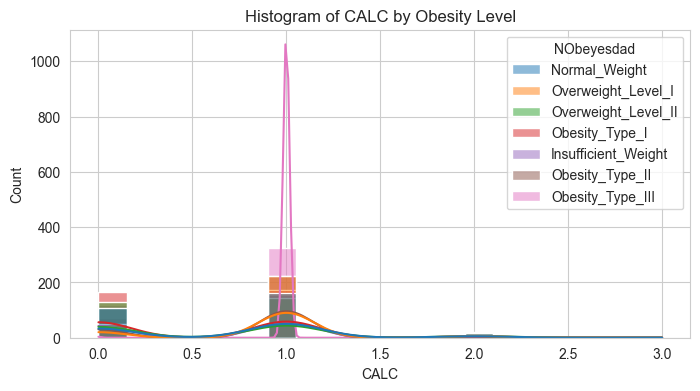

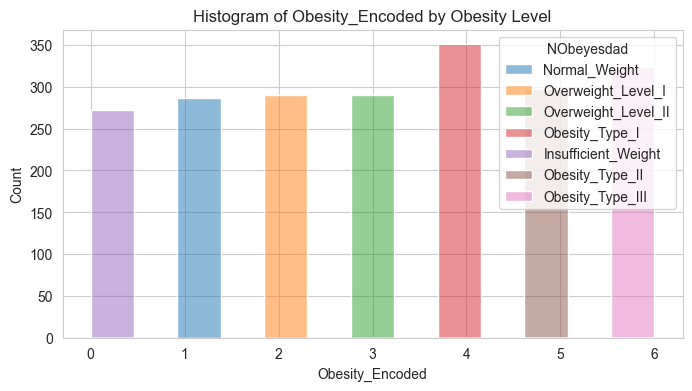

In [48]:
# Create histograms for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df, x=df[col], hue="NObeyesdad", kde=True)  # Histogram with KDE (density curve)
    plt.title(f"Histogram of {col} by Obesity Level")
    plt.savefig(f"figures/conditional_his/{col}.png")
    plt.show()

#### 4.6 **Correlation heatmap**

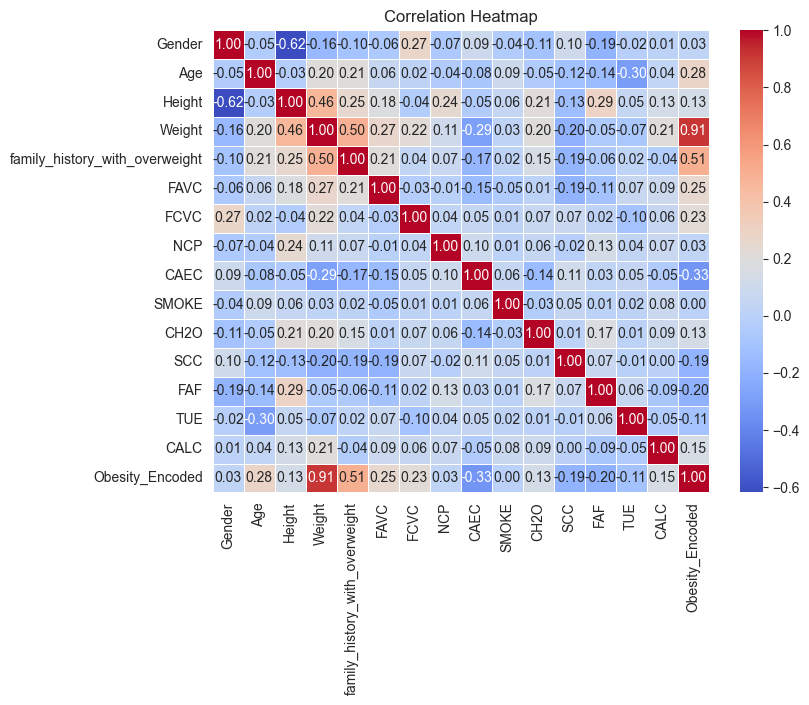

In [49]:
# Compute correlation matrix (only for numeric columns)
corr_matrix = df.select_dtypes(include=['number']).corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.savefig("figures/heatmap.png")
plt.show()


### 5. Non numeric data

the only feature that I couldn't encode was mean of transportation as it is really hard to define any particular order of this classes (where in time frequency it was pretty obvious)

therefore the correlation of this feature and obesity is shown below

In [50]:
# Create a contingency table
contingency_table = pd.crosstab(df['MTRANS'], df['NObeyesdad'])

# Display the contingency table
print(contingency_table)


NObeyesdad             Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
MTRANS                                                                      
Automobile                              46             45             110   
Bike                                     0              4               0   
Motorbike                                0              6               3   
Public_Transportation                  220            200             236   
Walking                                  6             32               2   

NObeyesdad             Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
MTRANS                                                                         
Automobile                          95                 1                  66   
Bike                                 1                 0                   2   
Motorbike                            0                 0                   1   
Public_Transportation              200               323    

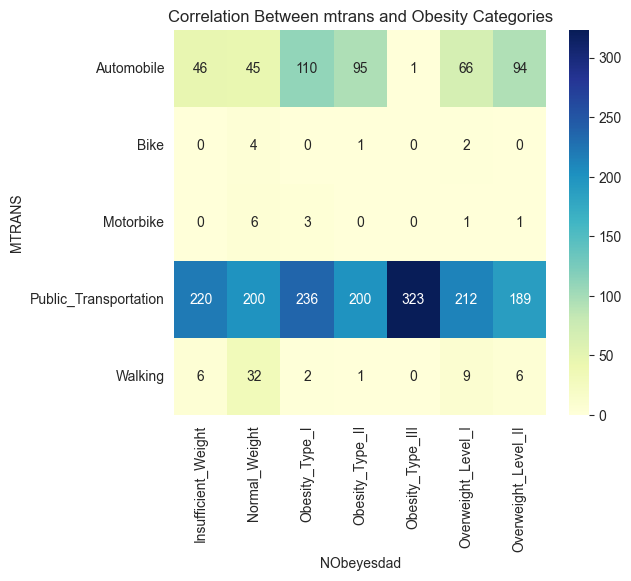

In [51]:
# Plot the heatmap of the contingency table
plt.figure(figsize=(6, 5))
sns.heatmap(contingency_table, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Correlation Between mtrans and Obesity Categories")
plt.savefig("figures/mtrans_heatmap.png")
plt.show()


### 6. Regression analysis

<Figure size 800x500 with 0 Axes>

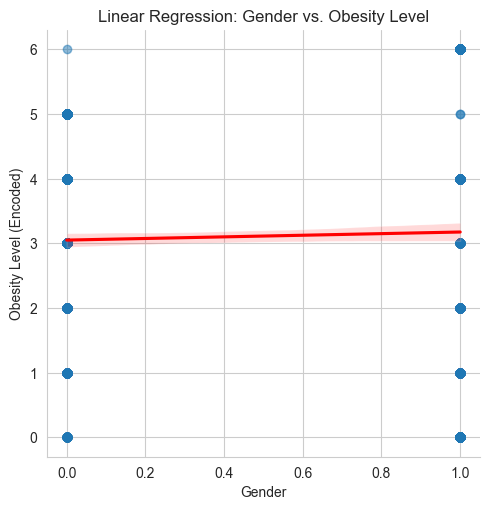

<Figure size 800x500 with 0 Axes>

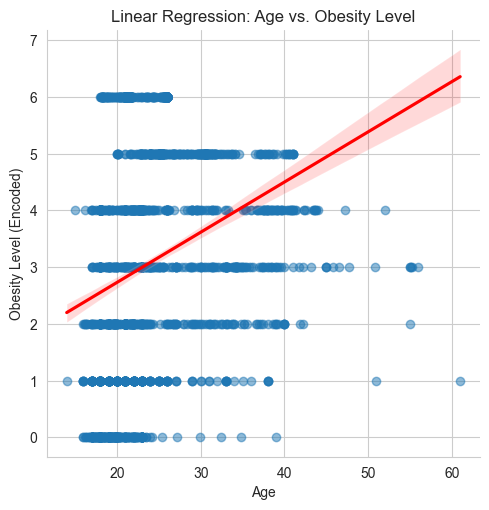

<Figure size 800x500 with 0 Axes>

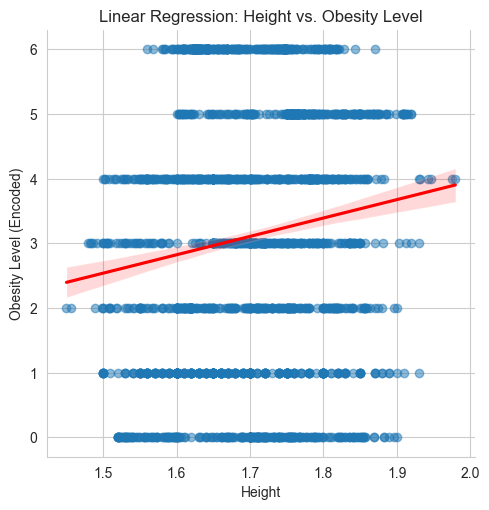

<Figure size 800x500 with 0 Axes>

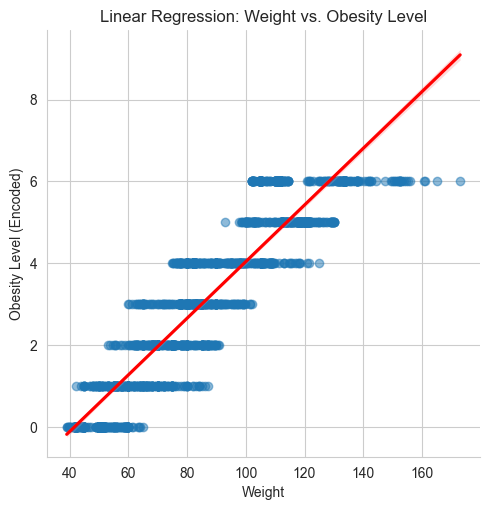

<Figure size 800x500 with 0 Axes>

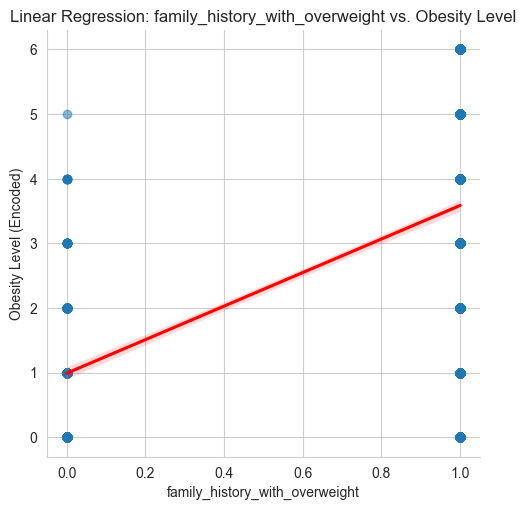

<Figure size 800x500 with 0 Axes>

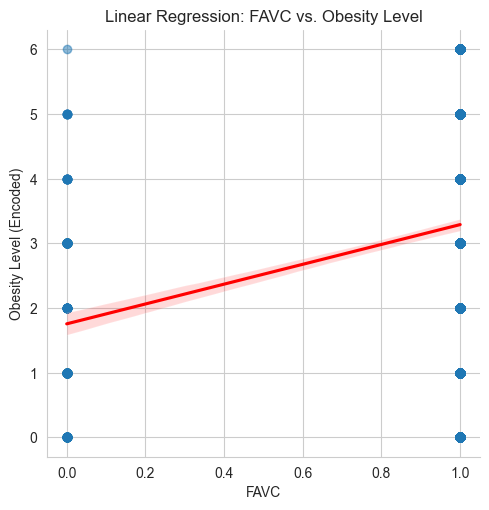

<Figure size 800x500 with 0 Axes>

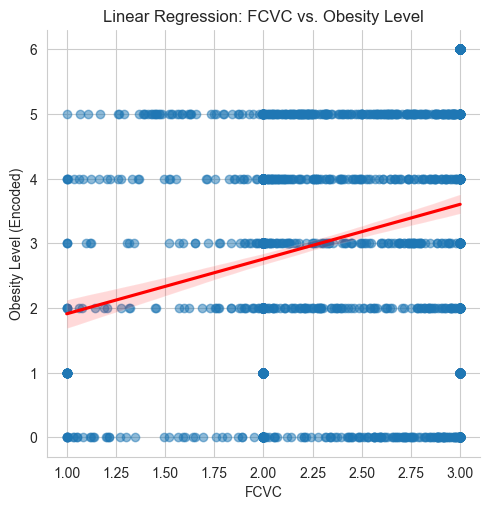

<Figure size 800x500 with 0 Axes>

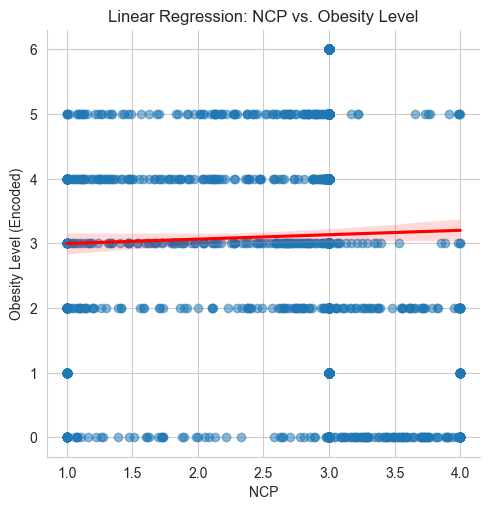

<Figure size 800x500 with 0 Axes>

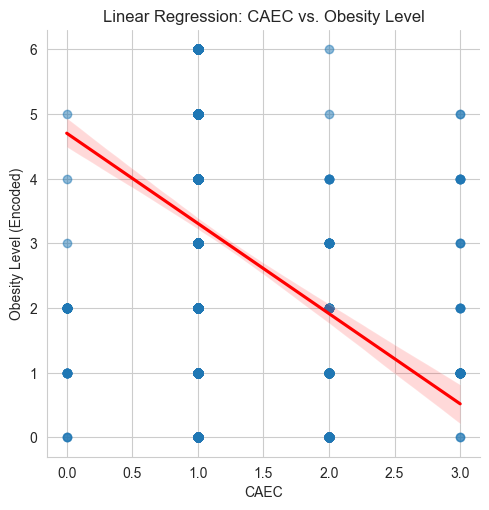

<Figure size 800x500 with 0 Axes>

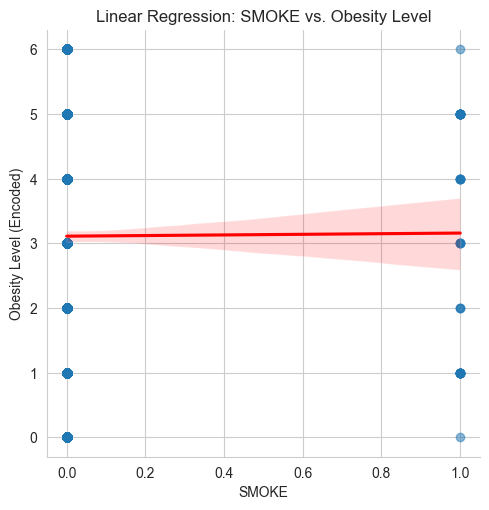

<Figure size 800x500 with 0 Axes>

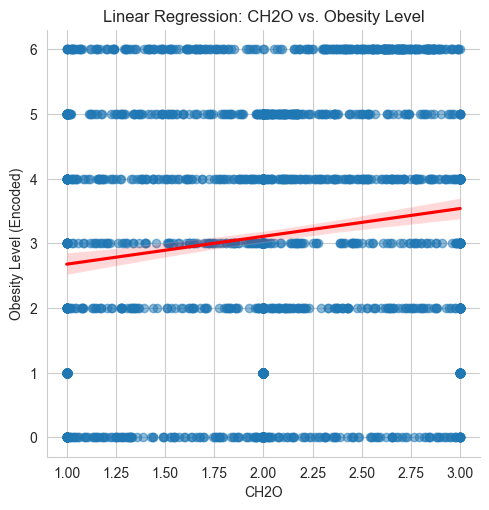

<Figure size 800x500 with 0 Axes>

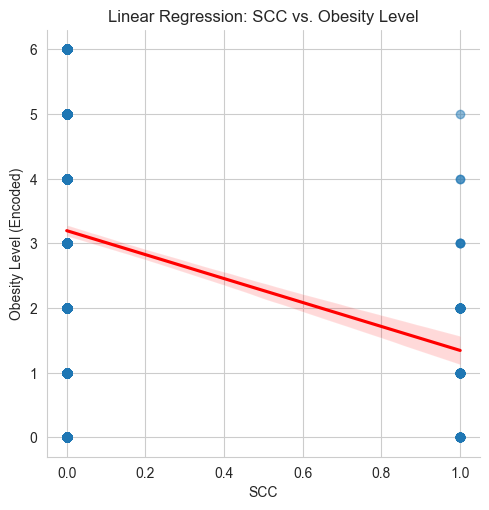

<Figure size 800x500 with 0 Axes>

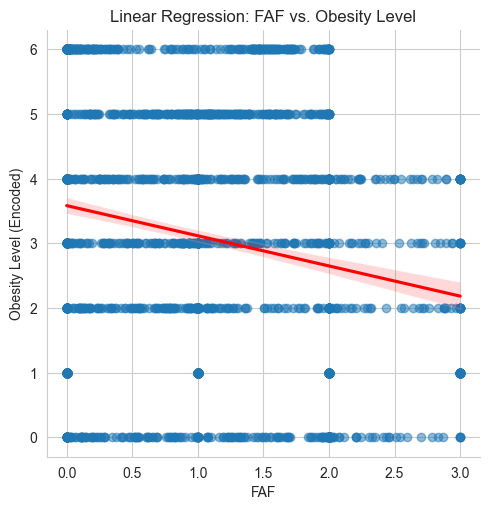

<Figure size 800x500 with 0 Axes>

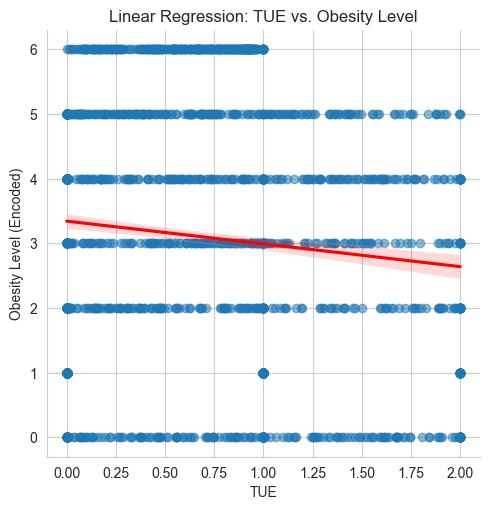

<Figure size 800x500 with 0 Axes>

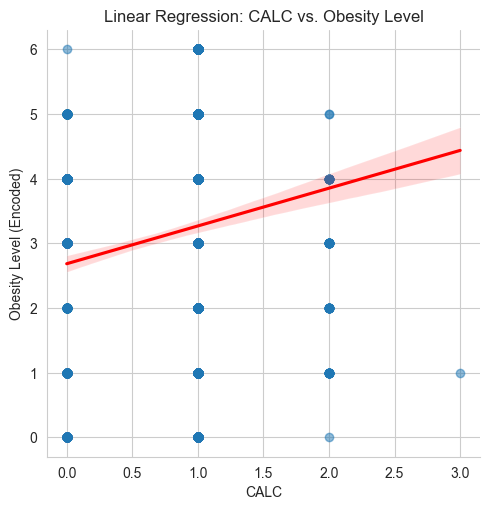

<Figure size 800x500 with 0 Axes>

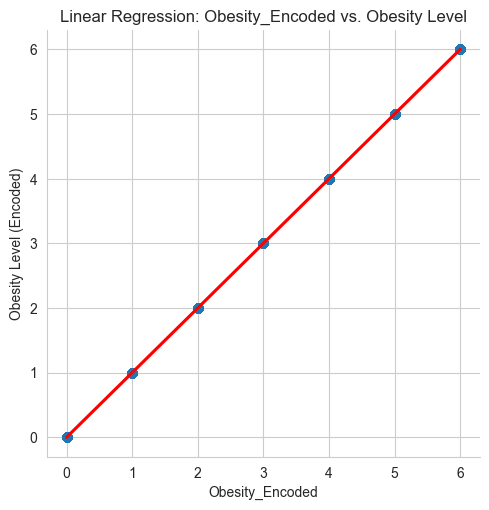

In [52]:
# Regression plots for each numeric feature vs. encoded obesity level
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.lmplot(data=df, x=col, y="Obesity_Encoded", scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f"Linear Regression: {col} vs. Obesity Level")
    plt.xlabel(col)
    plt.ylabel("Obesity Level (Encoded)")
    plt.savefig(f"figures/regression/{col}.png")
    plt.show()


**Multi - features regression**

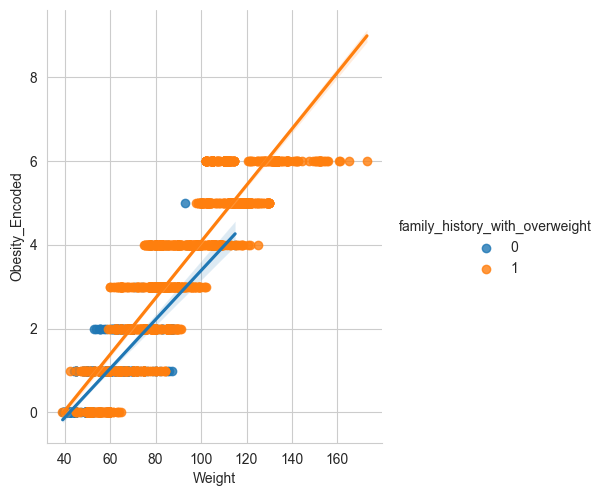

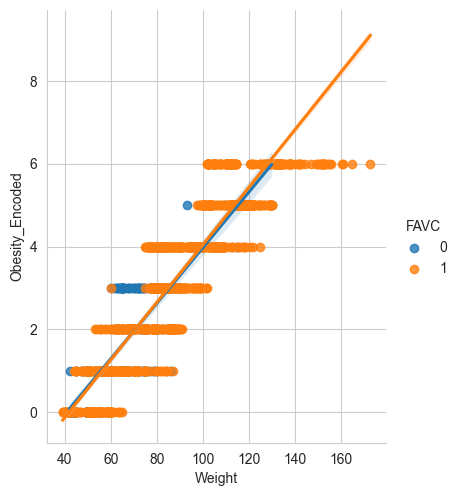

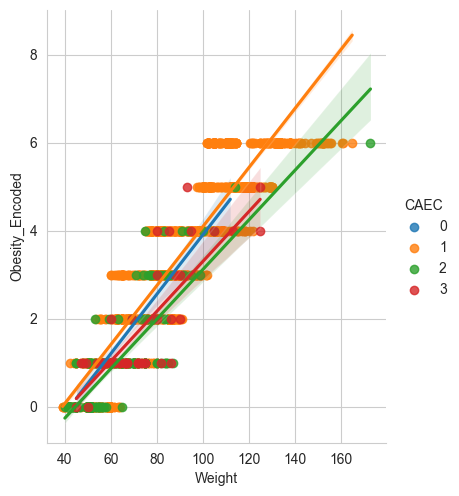

In [53]:
important_features = ['family_history_with_overweight', 'FAVC', 'CAEC']
for col in important_features:
    sns.pairplot(df, x_vars=["Weight"], y_vars=["Obesity_Encoded"],
                hue=col, height=5, aspect=.8, kind="reg")


### 7 Data visualization using dimensionality reduction

#### 7.1 Data visualization with PCA

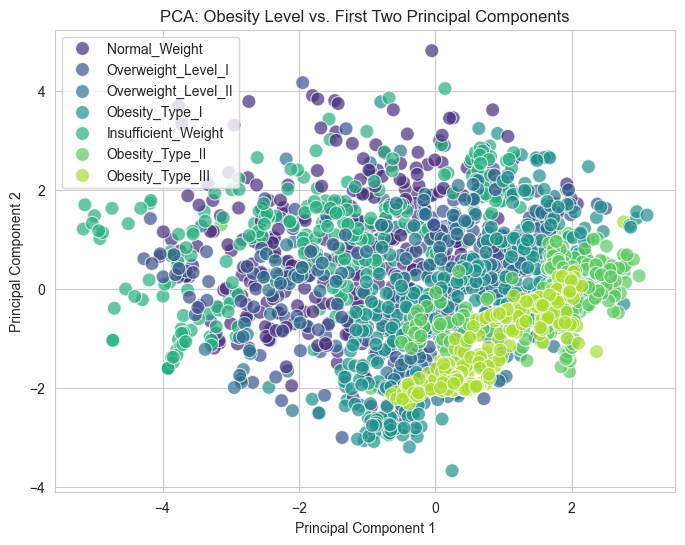

In [54]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data (important for PCA)
features = numeric_cols.tolist()
features.remove('Obesity_Encoded') # we take all numeric features except the encoded obesity
X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_components = pca.fit_transform(X_scaled)

# DataFrame for the PCA results
df_pca = pd.DataFrame(data=pca_components, columns=["PCA1", "PCA2"])

# Add the obesity categories for coloring
df_pca["Obesity_Level"] = df["NObeyesdad"].values

# Plot the PCA result
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PCA1", y="PCA2", hue="Obesity_Level", palette="viridis", s=100, alpha=0.7)
plt.title("PCA: Obesity Level vs. First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.savefig("figures/pca.png")
plt.show()


#### 7.2 Data visualization with t-SNE

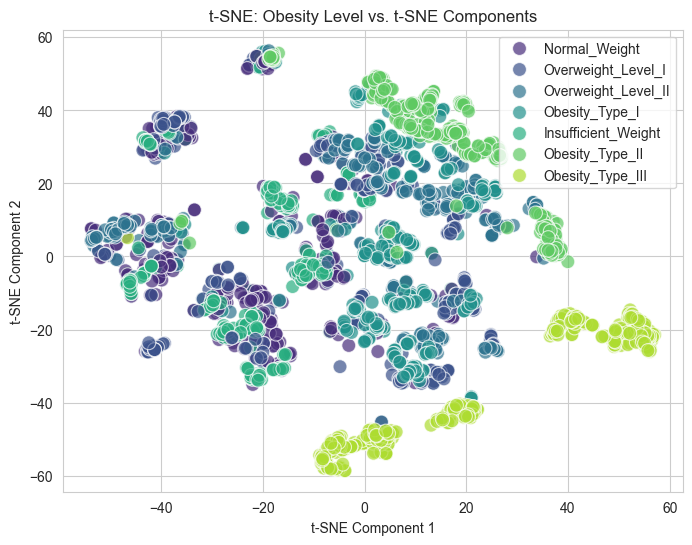

In [55]:
from sklearn.manifold import TSNE

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)  # Reduce to 2 components
tsne_components = tsne.fit_transform(X_scaled)

# Create a DataFrame for the t-SNE results
df_tsne = pd.DataFrame(data=tsne_components, columns=["tSNE1", "tSNE2"])

# Add the obesity categories for coloring
df_tsne["Obesity_Level"] = df["NObeyesdad"].values

# Plot the t-SNE result
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_tsne, x="tSNE1", y="tSNE2", hue="Obesity_Level", palette="viridis", s=100, alpha=0.7)
plt.title("t-SNE: Obesity Level vs. t-SNE Components")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.savefig("figures/tsne.png")
plt.show()


## Part 2 - Machine Learning Model

#### 1. Data processing

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# feature types
numeric_features = df.select_dtypes(include=['number']).drop(columns=['Obesity_Encoded']).columns
categorical_features = df.select_dtypes(include=['object']).drop(columns=['NObeyesdad']).columns

In [7]:
# numeric columns - empty replaced by mean, scaled so mean = 0 and stddev = 1
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# categorical columns - empty replaced by most frequent, one hot encoder - categorical data to numeric (e.g. binary vectors)
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [8]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

#### 2. Spliting into training, validation and test set - 60/20/20

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['NObeyesdad', 'Obesity_Encoded'])
y = df['Obesity_Encoded']

# (train + val) 80/20 test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 3. Running 3 different models: Linear Regression, Decision Tree, SVM 

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    # predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    print(f"\n=== {name} ===")
    print("Train set:")
    print(classification_report(y_train, y_train_pred))
    print("Test set:")
    print(classification_report(y_test, y_test_pred))


=== Logistic Regression ===
Train set:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       216
           1       0.89      0.75      0.81       225
           2       0.78      0.80      0.79       234
           3       0.80      0.81      0.81       240
           4       0.93      0.91      0.92       273
           5       0.95      0.99      0.97       239
           6       1.00      1.00      1.00       261

    accuracy                           0.89      1688
   macro avg       0.89      0.89      0.89      1688
weighted avg       0.89      0.89      0.89      1688

Test set:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        56
           1       0.89      0.63      0.74        62
           2       0.75      0.80      0.78        56
           3       0.81      0.86      0.83        50
           4       0.95      0.90      0.92        78
           5       0.89     

## Part III - optymalization

#### 1. Manual linear regression closed form - kfold

As previous y was a categorical feature (Obesity level) we choose new Y which is Weight: 

In [98]:
X1 = df.drop(columns='Weight')
y1 = df['Weight']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

Self-implemented regression

In [99]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin

class MyLinearRegression(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.coefficients_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        # Add bias (intercept) term
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Closed-form solution: theta = (X^T X)^(-1) X^T y
        theta = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        
        self.intercept_ = theta[0]
        self.coefficients_ = theta[1:]
        return self

    def predict(self, X):
        X = np.asarray(X)
        return X.dot(self.coefficients_) + self.intercept_

In [100]:
# from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate

numerical_features = X_train1.select_dtypes(include=['number']).columns
categorical_features = X_train1.select_dtypes(include=['object']).columns

# processing
preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])


linear_regression_pipeline = Pipeline([
    ('preprocessor', preprocessor1),
    ('regressor', MyLinearRegression()) 
])

In [101]:
scoring = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
cv_results = cross_validate(linear_regression_pipeline, X_train1, y_train1, cv=3, scoring=scoring)

# each fold results
print("\n=== Cross-Validation Results per Fold ===")
for i in range(cv_results['test_neg_mean_squared_error'].shape[0]):
    mse = -cv_results['test_neg_mean_squared_error'][i]
    mae = -cv_results['test_neg_mean_absolute_error'][i]
    r2 = cv_results['test_r2'][i]
    print(f"Fold {i+1}:")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R2 Score: {r2:.2f}")

# mean results
print("\n=== Mean Cross-Validation Results ===")
print(f"Mean MSE: {-cv_results['test_neg_mean_squared_error'].mean():.2f} (Std: {cv_results['test_neg_mean_squared_error'].std():.2f})")
print(f"Mean MAE: {-cv_results['test_neg_mean_absolute_error'].mean():.2f} (Std: {cv_results['test_neg_mean_absolute_error'].std():.2f})")
print(f"Mean R2: {cv_results['test_r2'].mean():.2f} (Std: {cv_results['test_r2'].std():.2f})")


=== Cross-Validation Results per Fold ===
Fold 1:
  MSE: 25.34
  MAE: 3.72
  R2 Score: 0.96
Fold 2:
  MSE: 26.80
  MAE: 3.84
  R2 Score: 0.96
Fold 3:
  MSE: 27.68
  MAE: 3.81
  R2 Score: 0.96

=== Mean Cross-Validation Results ===
Mean MSE: 26.61 (Std: 0.97)
Mean MAE: 3.79 (Std: 0.05)
Mean R2: 0.96 (Std: 0.00)


Training and test set results: 

In [102]:
# final fit
linear_regression_pipeline.fit(X_train1, y_train1)

# predict
y_train_pred = linear_regression_pipeline.predict(X_train1)
y_test_pred = linear_regression_pipeline.predict(X_test1)

# results
print("\n=== Linear Regression ===")
print("Train set:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_train1, y_train_pred):.2f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_train1, y_train_pred):.2f}")
print(f"R2 Score: {r2_score(y_train1, y_train_pred):.2f}")
print("Test set:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test1, y_test_pred):.2f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test1, y_test_pred):.2f}")
print(f"R2 Score: {r2_score(y_test1, y_test_pred):.2f}")


=== Linear Regression ===
Train set:
Mean Squared Error (MSE): 25.86
Mean Absolute Error (MAE): 3.74
R2 Score: 0.96
Test set:
Mean Squared Error (MSE): 25.94
Mean Absolute Error (MAE): 3.66
R2 Score: 0.96


#### Polynomial features

##### 2.1 Logistic Regression

In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('poly_features', PolynomialFeatures(include_bias=False)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'poly_features__degree': [1, 2, 3, 4]
}

# cross validation of 5 (StartfieldKFold) and best model based on f1 weighted
print("Looking for best params ...")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

# Grid Search 
grid_search.fit(X_train, y_train)

# Results
print("\n--- Results GridSearchCV ---")
print(f"Best params: {grid_search.best_params_}")
print(f"Best result (F1-weighted): {grid_search.best_score_:.4f}")

# Evaluation
best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print(f"\n--- Best model {grid_search.best_params_} (train set) ---")
print(classification_report(y_train, y_train_pred))

print(f"\n--- Best model {grid_search.best_params_} (test set) ---")
print(classification_report(y_test, y_test_pred))

Looking for best params ...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

--- Results GridSearchCV ---
Best params: {'poly_features__degree': 2}
Best result (F1-weighted): 0.8999

--- Best model {'poly_features__degree': 2} (train set) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       225
           2       1.00      0.99      0.99       234
           3       0.99      0.99      0.99       240
           4       1.00      1.00      1.00       273
           5       1.00      1.00      1.00       239
           6       1.00      1.00      1.00       261

    accuracy                           1.00      1688
   macro avg       1.00      1.00      1.00      1688
weighted avg       1.00      1.00      1.00      1688


--- Best model {'poly_features__degree': 2} (test set) ---
              precision    recall  f1-score   support

           0       0.95      1.00

##### 2.2 Softmax Regression (Gradient Descent)

In [18]:
# Transform data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Convert y to numpy
y_train_transformed = y_train.to_numpy()
y_test_transformed = y_test.to_numpy()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot(y, num_classes):
    one_hot_y = np.zeros((y.size, num_classes))
    one_hot_y[np.arange(y.size), y] = 1
    return one_hot_y

def cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.sum(y_true * np.log(y_pred)) / m

def softmax_regression_gd(X_train, y_train, X_test, y_test, num_classes, lr=0.1, epochs=1000, batch_size=64):
    m_train, n = X_train.shape
    m_test = X_test.shape[0]

    y_train_encoded = one_hot(y_train, num_classes)
    y_test_encoded = one_hot(y_test, num_classes)

    W = np.zeros((n, num_classes))
    b = np.zeros((1, num_classes))

    train_loss_history = []
    test_loss_history = []

    for epoch in range(epochs):
        indices = np.arange(m_train)
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        y_shuffled = y_train_encoded[indices]

        epoch_train_loss_sum = 0

        for start in range(0, m_train, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            logits = np.dot(X_batch, W) + b
            probs = softmax(logits)

            batch_loss = cross_entropy(y_batch, probs)
            epoch_train_loss_sum += batch_loss * X_batch.shape[0]

            dW = np.dot(X_batch.T, (probs - y_batch)) / X_batch.shape[0]
            db = np.sum(probs - y_batch, axis=0, keepdims=True) / X_batch.shape[0]

            W -= lr * dW
            b -= lr * db

        # Calculate average training loss for the epoch
        avg_epoch_train_loss = epoch_train_loss_sum / m_train
        train_loss_history.append(avg_epoch_train_loss)

        # Evaluation on test set for the current epoch (no gradient update)
        test_logits = np.dot(X_test, W) + b
        test_probs = softmax(test_logits)
        avg_epoch_test_loss = cross_entropy(y_test_encoded, test_probs)
        test_loss_history.append(avg_epoch_test_loss)

        if epoch % 100 == 0: # Print progress
            print(f"Epoch {epoch}: Train Loss = {avg_epoch_train_loss:.4f}, Test Loss = {avg_epoch_test_loss:.4f}")

    return W, b, train_loss_history, test_loss_history

Epoch 0: Train Loss = 1.6710, Test Loss = 1.4620
Epoch 100: Train Loss = 0.5469, Test Loss = 0.5590
Epoch 200: Train Loss = 0.4562, Test Loss = 0.4655
Epoch 300: Train Loss = 0.4065, Test Loss = 0.4163
Epoch 400: Train Loss = 0.3733, Test Loss = 0.3792
Epoch 500: Train Loss = 0.3485, Test Loss = 0.3529
Epoch 600: Train Loss = 0.3287, Test Loss = 0.3350
Epoch 700: Train Loss = 0.3127, Test Loss = 0.3181
Epoch 800: Train Loss = 0.2991, Test Loss = 0.3053
Epoch 900: Train Loss = 0.2873, Test Loss = 0.2940


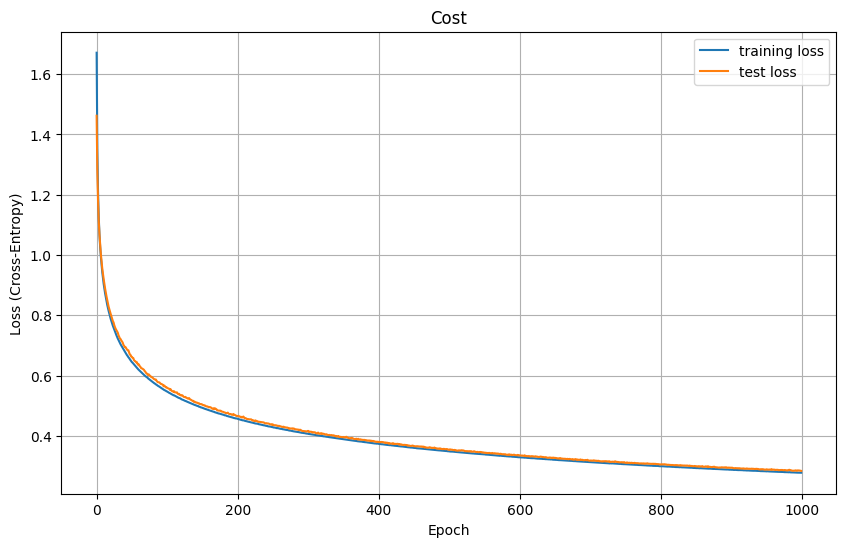


--- Classification report ---
Train set:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       216
           1       0.93      0.85      0.89       225
           2       0.85      0.86      0.85       234
           3       0.90      0.88      0.89       240
           4       0.96      0.96      0.96       273
           5       0.97      0.99      0.98       239
           6       1.00      1.00      1.00       261

    accuracy                           0.93      1688
   macro avg       0.93      0.93      0.93      1688
weighted avg       0.93      0.93      0.93      1688


Test set:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        56
           1       0.90      0.76      0.82        62
           2       0.79      0.80      0.80        56
           3       0.82      0.90      0.86        50
           4       0.99      0.94      0.96        78
           5       0.95  

In [20]:
num_classes = len(np.unique(y_train_transformed))
epochs = 1000

W, b, train_loss_hist, test_loss_hist = softmax_regression_gd(
    X_train_transformed, y_train_transformed,
    X_test_transformed, y_test_transformed,
    num_classes=num_classes,
)

plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_loss_hist, label='training loss')
plt.plot(range(epochs), test_loss_hist, label='test loss')
plt.title('Cost')
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()

def predict(X_data, W, b):
    logits = np.dot(X_data, W) + b
    return np.argmax(softmax(logits), axis=1)

print("\n--- Classification report ---")
y_train_pred = predict(X_train_transformed, W, b)
y_test_pred = predict(X_test_transformed, W, b)

print("Train set:")
print(classification_report(y_train_transformed, y_train_pred))

print("\nTest set:")
print(classification_report(y_test_transformed, y_test_pred))


Gradient descent more features

Epoch 0: Train Loss = 1.6912, Test Loss = 1.4816
Epoch 100: Train Loss = 0.3230, Test Loss = 0.4551
Epoch 200: Train Loss = 0.2434, Test Loss = 0.4027
Epoch 300: Train Loss = 0.2032, Test Loss = 0.3807
Epoch 400: Train Loss = 0.1772, Test Loss = 0.3667
Epoch 500: Train Loss = 0.1588, Test Loss = 0.3593
Epoch 600: Train Loss = 0.1445, Test Loss = 0.3545
Epoch 700: Train Loss = 0.1332, Test Loss = 0.3515
Epoch 800: Train Loss = 0.1240, Test Loss = 0.3474
Epoch 900: Train Loss = 0.1163, Test Loss = 0.3460


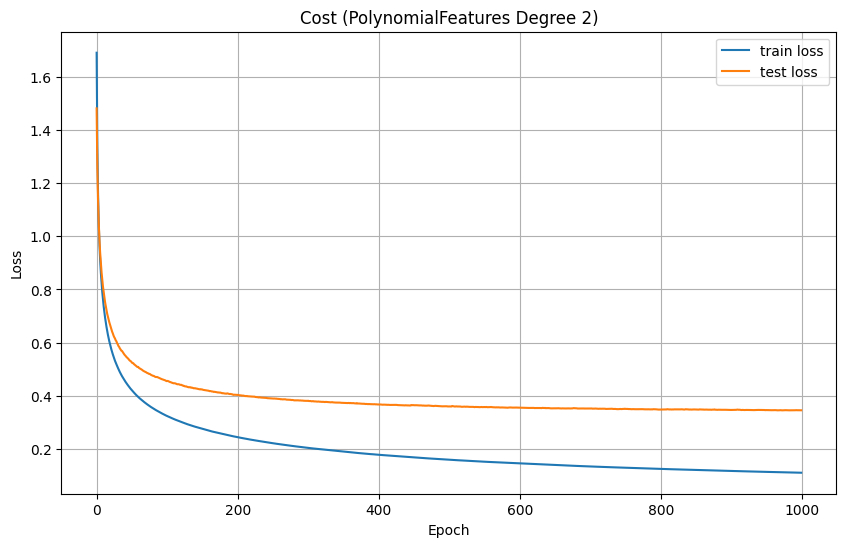


--- Gradient descent with poly features ---
Train set:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       216
           1       0.98      0.96      0.97       225
           2       0.94      0.95      0.95       234
           3       0.96      0.95      0.96       240
           4       0.99      1.00      0.99       273
           5       1.00      1.00      1.00       239
           6       1.00      1.00      1.00       261

    accuracy                           0.98      1688
   macro avg       0.98      0.98      0.98      1688
weighted avg       0.98      0.98      0.98      1688


Test set:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        56
           1       0.84      0.76      0.80        62
           2       0.80      0.79      0.79        56
           3       0.82      0.84      0.83        50
           4       0.94      0.94      0.94        78
           

In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False) 
X_train_poly = poly.fit_transform(X_train_transformed)
X_test_poly = poly.transform(X_test_transformed)

W_poly, b_poly, train_loss_poly, test_loss_poly = softmax_regression_gd(
    X_train_poly, y_train_transformed,
    X_test_poly, y_test_transformed,
    num_classes=num_classes,
    lr=0.01
)

plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_loss_poly, label='train loss')
plt.plot(range(epochs), test_loss_poly, label='test loss')
plt.title('Cost (PolynomialFeatures Degree 2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

def predict(X_data, W, b):
    logits = np.dot(X_data, W) + b
    return np.argmax(softmax(logits), axis=1)

print("\n--- Gradient descent with poly features ---")
y_train_pred_gd = predict(X_train_poly, W_poly, b_poly)
y_test_pred_gd = predict(X_test_poly, W_poly, b_poly)

print("Train set:")
print(classification_report(y_train, y_train_pred_gd))

print("\nTest set:")
print(classification_report(y_test, y_test_pred_gd))

Gradient descent less features

In [22]:
transformed_feature_names = preprocessor.get_feature_names_out()
for i, name in enumerate(transformed_feature_names):
    print(f"Column {i}: {name}")

Column 0: num__Age
Column 1: num__Height
Column 2: num__Weight
Column 3: num__FCVC
Column 4: num__NCP
Column 5: num__CAEC
Column 6: num__CH2O
Column 7: num__FAF
Column 8: num__TUE
Column 9: num__CALC
Column 10: cat__Gender_Female
Column 11: cat__Gender_Male
Column 12: cat__family_history_with_overweight_no
Column 13: cat__family_history_with_overweight_yes
Column 14: cat__FAVC_no
Column 15: cat__FAVC_yes
Column 16: cat__SMOKE_no
Column 17: cat__SMOKE_yes
Column 18: cat__SCC_no
Column 19: cat__SCC_yes
Column 20: cat__MTRANS_Automobile
Column 21: cat__MTRANS_Bike
Column 22: cat__MTRANS_Motorbike
Column 23: cat__MTRANS_Public_Transportation
Column 24: cat__MTRANS_Walking


In [23]:
from sklearn.feature_selection import SelectKBest, f_classif

k = 16

data_transformer_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=k)) # best k features
])

X_train_selected = data_transformer_pipeline.fit_transform(X_train, y_train)
X_test_selected = data_transformer_pipeline.transform(X_test) 

selected_features_mask = data_transformer_pipeline.named_steps['selector'].get_support()
transformed_feature_names_all = data_transformer_pipeline.named_steps['preprocessor'].get_feature_names_out()

print("\nSelected features:")
for i, name in enumerate(transformed_feature_names_all):
    if selected_features_mask[i]:
        print(f"{i} - {name}")


Selected features:
0 - num__Age
1 - num__Height
2 - num__Weight
3 - num__FCVC
4 - num__NCP
5 - num__CAEC
9 - num__CALC
10 - cat__Gender_Female
11 - cat__Gender_Male
12 - cat__family_history_with_overweight_no
13 - cat__family_history_with_overweight_yes
14 - cat__FAVC_no
15 - cat__FAVC_yes
19 - cat__SCC_yes
20 - cat__MTRANS_Automobile
23 - cat__MTRANS_Public_Transportation


Epoch 0: Train Loss = 1.6821, Test Loss = 1.4824
Epoch 100: Train Loss = 0.5725, Test Loss = 0.5679
Epoch 200: Train Loss = 0.4769, Test Loss = 0.4687
Epoch 300: Train Loss = 0.4252, Test Loss = 0.4132
Epoch 400: Train Loss = 0.3910, Test Loss = 0.3762
Epoch 500: Train Loss = 0.3652, Test Loss = 0.3504
Epoch 600: Train Loss = 0.3451, Test Loss = 0.3286
Epoch 700: Train Loss = 0.3282, Test Loss = 0.3119
Epoch 800: Train Loss = 0.3143, Test Loss = 0.2977
Epoch 900: Train Loss = 0.3021, Test Loss = 0.2858


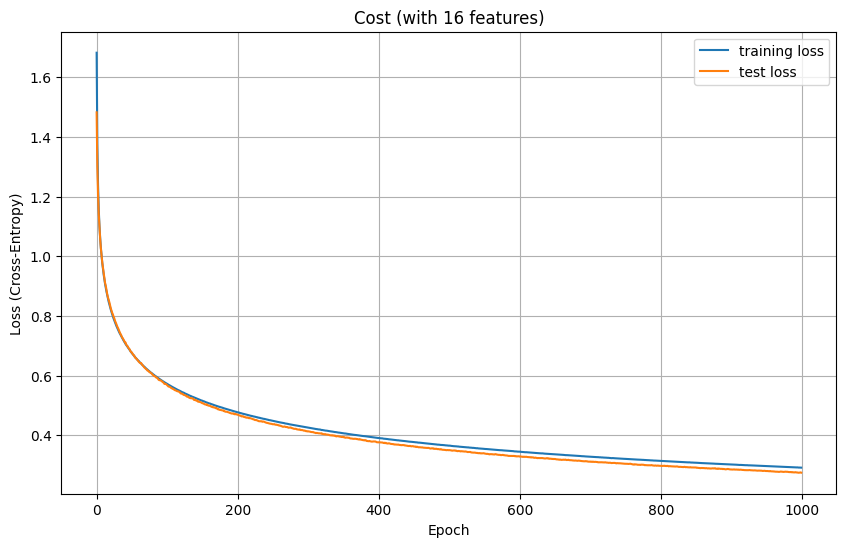


--- Gradient descent with 16 features ---
Train set:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       216
           1       0.93      0.84      0.88       225
           2       0.86      0.88      0.87       234
           3       0.91      0.88      0.90       240
           4       0.96      0.97      0.96       273
           5       0.98      0.99      0.99       239
           6       1.00      1.00      1.00       261

    accuracy                           0.94      1688
   macro avg       0.94      0.94      0.93      1688
weighted avg       0.94      0.94      0.94      1688

Test set:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        56
           1       0.96      0.79      0.87        62
           2       0.85      0.91      0.88        56
           3       0.88      0.90      0.89        50
           4       0.97      0.92      0.95        78
           5  

In [24]:
W_custom_gd, b_custom_gd, train_loss_hist, test_loss_hist = softmax_regression_gd(
    X_train_selected, y_train, 
    X_test_selected, y_test, 
    num_classes=num_classes
)

plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_loss_hist, label='training loss')
plt.plot(range(epochs), test_loss_hist, label='test loss')
plt.title(f'Cost (with {k} features)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()

def predict(X_data, W, b):
    logits = np.dot(X_data, W) + b
    return np.argmax(softmax(logits), axis=1)

print(f"\n--- Gradient descent with {k} features ---")
y_train_pred_gd = predict(X_train_selected, W_custom_gd, b_custom_gd)
y_test_pred_gd = predict(X_test_selected, W_custom_gd, b_custom_gd)

print("Train set:")
print(classification_report(y_train, y_train_pred_gd))

print("Test set:")
print(classification_report(y_test, y_test_pred_gd))

### 3. Regularization 

#### 3.1 Logistic regression

In [15]:
import numpy as np
fixed_poly_degree = 2

# None 
pipeline_no_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('poly_features', PolynomialFeatures(degree=fixed_poly_degree, include_bias=False)),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', penalty='l2', C=1e9)) # minimal regularization
])
pipeline_no_reg.fit(X_train, y_train)
model_no_reg = pipeline_no_reg.named_steps['classifier']

# Lasso
pipeline_l1_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('poly_features', PolynomialFeatures(degree=fixed_poly_degree, include_bias=False)),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', penalty='l1'))
])

pipeline_l1_reg.fit(X_train, y_train)
model_l1_reg = pipeline_l1_reg.named_steps['classifier']

#Ridge
pipeline_l2_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('poly_features', PolynomialFeatures(degree=fixed_poly_degree, include_bias=False)),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', penalty='l2'))
])
pipeline_l2_reg.fit(X_train, y_train)
model_l2_reg = pipeline_l2_reg.named_steps['classifier']

Extarct Weights

In [16]:
# features names
temp_transformed_X_train = preprocessor.fit_transform(X_train)
preprocessor_feature_names = preprocessor.get_feature_names_out()

poly_features_temp = PolynomialFeatures(degree=fixed_poly_degree, include_bias=False)
dummy_data_for_poly_fit = np.zeros((1, temp_transformed_X_train.shape[1]))
poly_features_temp.fit(dummy_data_for_poly_fit)
transformed_poly_feature_names = poly_features_temp.get_feature_names_out(preprocessor_feature_names)


weights_no_reg = model_no_reg.coef_[0] if model_no_reg.coef_.ndim > 1 else model_no_reg.coef_
weights_l1_reg = model_l1_reg.coef_[0] if model_l1_reg.coef_.ndim > 1 else model_l1_reg.coef_
weights_l2_reg = model_l2_reg.coef_[0] if model_l2_reg.coef_.ndim > 1 else model_l2_reg.coef_


# dataframe for better visualization
weights_df = pd.DataFrame({
    'Feature': transformed_poly_feature_names,
    'None': weights_no_reg,
    'L1': weights_l1_reg,
    'L2': weights_l2_reg
})

weights_df['Abs'] = np.abs(weights_df['None'])
weights_df = weights_df.sort_values(by='Abs', ascending=False).drop(columns=['Abs'])

print("\n--- Weights comparison---")
print(weights_df.to_string()) 


--- Weights comparison---
                                                                            Feature      None        L1        L2
74                                                                    num__Weight^2  9.817481  4.083375  2.524488
27                                                             num__Age num__Weight  3.648405  0.303824  0.792890
95                                    num__Weight cat__MTRANS_Public_Transportation -3.600946 -1.601481 -1.034230
53                                                             num__Height num__NCP  3.560287  0.353028  0.839303
90                                                          num__Weight cat__SCC_no -2.881460  0.000000 -0.921979
2                                                                       num__Weight -2.841407 -1.205011 -0.916967
30                                                               num__Age num__CAEC  2.736050  0.443512  0.768471
88                                                        num

Classification reports

In [17]:
print("\n--- No regularization ---")
y_train_pred_no_reg = pipeline_no_reg.predict(X_train)
y_test_pred_no_reg = pipeline_no_reg.predict(X_test)
print("train set:")
print(classification_report(y_train, y_train_pred_no_reg))
print("test set:")
print(classification_report(y_test, y_test_pred_no_reg))

print("---  L1 ---")
y_train_pred_l1_reg = pipeline_l1_reg.predict(X_train)
y_test_pred_l1_reg = pipeline_l1_reg.predict(X_test)
print("train set:")
print(classification_report(y_train, y_train_pred_l1_reg))
print("test set:")
print(classification_report(y_test, y_test_pred_l1_reg))

print("--- L2 ---")
y_train_pred_l2_reg = pipeline_l2_reg.predict(X_train)
y_test_pred_l2_reg = pipeline_l2_reg.predict(X_test)
print("train set:")
print(classification_report(y_train, y_train_pred_l2_reg))
print("test set:")
print(classification_report(y_test, y_test_pred_l2_reg))


--- No regularization ---
train set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       234
           3       1.00      1.00      1.00       240
           4       1.00      1.00      1.00       273
           5       1.00      1.00      1.00       239
           6       1.00      1.00      1.00       261

    accuracy                           1.00      1688
   macro avg       1.00      1.00      1.00      1688
weighted avg       1.00      1.00      1.00      1688

test set:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        56
           1       0.88      0.81      0.84        62
           2       0.78      0.82      0.80        56
           3       0.83      0.78      0.80        50
           4       0.95      0.92      0.94        78
           5       0.93      0

#### 3.2 Gradient descent 

In [25]:
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot(y, num_classes):
    one_hot_y = np.zeros((y.size, num_classes))
    one_hot_y[np.arange(y.size), y] = 1
    return one_hot_y

def cross_entropy_with_regularization(y_true, y_pred, W, reg_lambda, penalty_type):
    m = y_true.shape[0]
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    loss = -np.sum(y_true * np.log(y_pred)) / m
    
    if penalty_type == 'l2':
        loss += (reg_lambda / (2 * m)) * np.sum(W**2)
    elif penalty_type == 'l1':
        loss += (reg_lambda / m) * np.sum(np.abs(W))
        
    return loss

def softmax_regression_gd_reg(X_train, y_train, X_test, y_test, num_classes,
                          lr=0.1, epochs=1000, batch_size=64,
                          reg_lambda=0.0, penalty_type=None, balancing_strategy=None):
    
    X_train_balanced, y_train_balanced = X_train.copy(), y_train.copy() # Start z oryginalnymi
    
    if balancing_strategy == 'smote':
        print(f"Original distribution: {Counter(y_train)}")
        smote = SMOTE(random_state=42)
        X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
        print(f"SMOTE distribution: {Counter(y_train_balanced)}")
    elif balancing_strategy == 'undersampling':
        print(f"Original distribution: {Counter(y_train)}")
        rus = RandomUnderSampler(random_state=42)
        X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)
        print(f"Undersampling distribution: {Counter(y_train_balanced)}")
    else:
        print("No balancing strategy applied.")

    m_train, n = X_train_balanced.shape

    y_train_encoded = one_hot(y_train_balanced, num_classes)
    y_test_encoded = one_hot(y_test, num_classes)

    W = np.zeros((n, num_classes))
    b = np.zeros((1, num_classes))

    train_loss_history = []
    test_loss_history = []

    for epoch in range(epochs):
        indices = np.arange(m_train)
        np.random.shuffle(indices)
        X_shuffled = X_train_balanced[indices]
        y_shuffled = y_train_encoded[indices]

        epoch_train_loss_sum = 0

        for start in range(0, m_train, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            current_batch_size = X_batch.shape[0] 

            logits = np.dot(X_batch, W) + b
            probs = softmax(logits)

            batch_loss = cross_entropy_with_regularization(y_batch, probs, W, reg_lambda, penalty_type)
            epoch_train_loss_sum += batch_loss * current_batch_size 
            
            dW = np.dot(X_batch.T, (probs - y_batch)) / current_batch_size
            db = np.sum(probs - y_batch, axis=0, keepdims=True) / current_batch_size

            # derivative
            if penalty_type == 'l2':
                dW += (reg_lambda / current_batch_size) * W 
            elif penalty_type == 'l1':
                dW += (reg_lambda / current_batch_size) * np.sign(W) 
            
            W -= lr * dW
            b -= lr * db

        avg_epoch_train_loss = cross_entropy_with_regularization(y_train_encoded, softmax(np.dot(X_train_balanced, W) + b), W, reg_lambda, penalty_type)
        train_loss_history.append(avg_epoch_train_loss)

        test_logits = np.dot(X_test, W) + b
        test_probs = softmax(test_logits)
        avg_epoch_test_loss = cross_entropy_with_regularization(y_test_encoded, test_probs, W, reg_lambda, penalty_type)
        test_loss_history.append(avg_epoch_test_loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Train Loss = {avg_epoch_train_loss:.4f}, Test Loss = {avg_epoch_test_loss:.4f}")

    return W, b, train_loss_history, test_loss_history


def predict_softmax(X, W, b):
    logits = np.dot(X, W) + b
    return np.argmax(softmax(logits), axis=1)

None:

In [26]:
W_custom_gd, b_custom_gd, train_loss_hist, test_loss_hist = softmax_regression_gd_reg(
    X_train_poly, y_train, 
    X_test_poly, y_test, 
    num_classes=num_classes
)

print(f"\n--- Gradient descent poly ---")
y_train_pred_gd = predict(X_train_poly, W_custom_gd, b_custom_gd)
y_test_pred_gd = predict(X_test_poly, W_custom_gd, b_custom_gd)

print("Train set:")
print(classification_report(y_train, y_train_pred_gd))

print("Test set:")
print(classification_report(y_test, y_test_pred_gd))

No balancing strategy applied.
Epoch 0: Train Loss = 0.7738, Test Loss = 0.8501
Epoch 100: Train Loss = 0.1104, Test Loss = 0.3539
Epoch 200: Train Loss = 0.0716, Test Loss = 0.3391
Epoch 300: Train Loss = 0.0554, Test Loss = 0.3472
Epoch 400: Train Loss = 0.0455, Test Loss = 0.3483
Epoch 500: Train Loss = 0.0390, Test Loss = 0.3504
Epoch 600: Train Loss = 0.0341, Test Loss = 0.3579
Epoch 700: Train Loss = 0.0305, Test Loss = 0.3586
Epoch 800: Train Loss = 0.0276, Test Loss = 0.3625
Epoch 900: Train Loss = 0.0253, Test Loss = 0.3715

--- Gradient descent poly ---
Train set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       234
           3       1.00      1.00      1.00       240
           4       1.00      1.00      1.00       273
           5       1.00      1.00      1.00       239
           6       1.00      1.00      1

L1: 

In [235]:
W_custom_gd, b_custom_gd, train_loss_hist, test_loss_hist = softmax_regression_gd_reg(
    X_train_poly, y_train, 
    X_test_poly, y_test, 
    num_classes=num_classes,
    reg_lambda=0.01, penalty_type='l1'
)

print(f"\n--- Gradient descent L1 ---")
y_train_pred_gd = predict(X_train_poly, W_custom_gd, b_custom_gd)
y_test_pred_gd = predict(X_test_poly, W_custom_gd, b_custom_gd)

print("Train set:")
print(classification_report(y_train, y_train_pred_gd))

print("Test set:")
print(classification_report(y_test, y_test_pred_gd))

No balancing strategy applied.
Epoch 0: Train Loss = 0.7610, Test Loss = 0.8189
Epoch 100: Train Loss = 0.1191, Test Loss = 0.3306
Epoch 200: Train Loss = 0.0885, Test Loss = 0.3353
Epoch 300: Train Loss = 0.0702, Test Loss = 0.3083
Epoch 400: Train Loss = 0.0616, Test Loss = 0.2980
Epoch 500: Train Loss = 0.0559, Test Loss = 0.2967
Epoch 600: Train Loss = 0.0517, Test Loss = 0.2894
Epoch 700: Train Loss = 0.0485, Test Loss = 0.2827
Epoch 800: Train Loss = 0.0461, Test Loss = 0.2782
Epoch 900: Train Loss = 0.0441, Test Loss = 0.2738

--- Gradient descent L1 ---
Train set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       225
           2       1.00      0.99      1.00       234
           3       0.99      1.00      0.99       240
           4       1.00      1.00      1.00       273
           5       1.00      1.00      1.00       239
           6       1.00      1.00      1.0

L2:

In [236]:
W_custom_gd, b_custom_gd, train_loss_hist, test_loss_hist = softmax_regression_gd_reg(
    X_train_poly, y_train, 
    X_test_poly, y_test, 
    num_classes=num_classes,
    reg_lambda=0.1, penalty_type='l2'
)

print(f"\n--- Gradient descent L2 ---")
y_train_pred_gd = predict(X_train_poly, W_custom_gd, b_custom_gd)
y_test_pred_gd = predict(X_test_poly, W_custom_gd, b_custom_gd)

print("Train set:")
print(classification_report(y_train, y_train_pred_gd))

print("Test set:")
print(classification_report(y_test, y_test_pred_gd))

No balancing strategy applied.
Epoch 0: Train Loss = 0.7560, Test Loss = 0.8232
Epoch 100: Train Loss = 0.1405, Test Loss = 0.3532
Epoch 200: Train Loss = 0.1210, Test Loss = 0.3576
Epoch 300: Train Loss = 0.1159, Test Loss = 0.3463
Epoch 400: Train Loss = 0.1145, Test Loss = 0.3454
Epoch 500: Train Loss = 0.1154, Test Loss = 0.3511
Epoch 600: Train Loss = 0.1144, Test Loss = 0.3519
Epoch 700: Train Loss = 0.1136, Test Loss = 0.3430
Epoch 800: Train Loss = 0.1133, Test Loss = 0.3444
Epoch 900: Train Loss = 0.1131, Test Loss = 0.3488

--- Gradient descent L2 ---
Train set:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       216
           1       0.99      0.97      0.98       225
           2       0.95      0.95      0.95       234
           3       0.97      0.96      0.96       240
           4       0.99      1.00      0.99       273
           5       1.00      1.00      1.00       239
           6       1.00      1.00      1.0

### 4. Balancing dataset

Although dataset is already more or less balanced for more controll we use balancing methods

##### 4.1 Oversampling (SMOTE)

In [29]:
W_poly, b_poly, train_loss_poly, test_loss_poly = softmax_regression_gd_reg(
    X_train_selected, y_train_transformed,
    X_test_selected, y_test_transformed,
    num_classes=num_classes,
    balancing_strategy = 'smote',
    reg_lambda=0.01, penalty_type='l1'
)

def predict(X_data, W, b):
    logits = np.dot(X_data, W) + b
    return np.argmax(softmax(logits), axis=1)

print("--- Gradient descent oversampling (SMOTE) ---")
y_train_pred_gd = predict(X_train_selected, W_poly, b_poly)
y_test_pred_gd = predict(X_test_selected, W_poly, b_poly)

print("Train set:")
print(classification_report(y_train, y_train_pred_gd))

print("Test set:")
print(classification_report(y_test, y_test_pred_gd))

Original distribution: Counter({np.int8(4): 273, np.int8(6): 261, np.int8(3): 240, np.int8(5): 239, np.int8(2): 234, np.int8(1): 225, np.int8(0): 216})
SMOTE distribution: Counter({np.int8(1): 273, np.int8(6): 273, np.int8(4): 273, np.int8(0): 273, np.int8(5): 273, np.int8(3): 273, np.int8(2): 273})
Epoch 0: Train Loss = 1.4447, Test Loss = 1.4632
Epoch 100: Train Loss = 0.5515, Test Loss = 0.5590
Epoch 200: Train Loss = 0.4600, Test Loss = 0.4610
Epoch 300: Train Loss = 0.4105, Test Loss = 0.4090
Epoch 400: Train Loss = 0.3774, Test Loss = 0.3743
Epoch 500: Train Loss = 0.3527, Test Loss = 0.3492
Epoch 600: Train Loss = 0.3333, Test Loss = 0.3283
Epoch 700: Train Loss = 0.3174, Test Loss = 0.3128
Epoch 800: Train Loss = 0.3041, Test Loss = 0.2989
Epoch 900: Train Loss = 0.2926, Test Loss = 0.2872
--- Gradient descent oversampling (SMOTE) ---
Train set:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       216
           1       0.93  

##### 4.2 Undersampling

In [28]:
W_poly, b_poly, train_loss_poly, test_loss_poly = softmax_regression_gd_reg(
    X_train_selected, y_train_transformed,
    X_test_selected, y_test_transformed,
    num_classes=num_classes,
    balancing_strategy='undersampling'
)

def predict(X_data, W, b):
    logits = np.dot(X_data, W) + b
    return np.argmax(softmax(logits), axis=1)

print("--- Gradient descent undersampling ---")
y_train_pred_gd = predict(X_train_selected, W_poly, b_poly)
y_test_pred_gd = predict(X_test_selected, W_poly, b_poly)

print("Train set:")
print(classification_report(y_train, y_train_pred_gd))

print("Test set:")
print(classification_report(y_test, y_test_pred_gd))

Original distribution: Counter({np.int8(4): 273, np.int8(6): 261, np.int8(3): 240, np.int8(5): 239, np.int8(2): 234, np.int8(1): 225, np.int8(0): 216})
Undersampling distribution: Counter({np.int8(0): 216, np.int8(1): 216, np.int8(2): 216, np.int8(3): 216, np.int8(4): 216, np.int8(5): 216, np.int8(6): 216})
Epoch 0: Train Loss = 1.5054, Test Loss = 1.5200
Epoch 100: Train Loss = 0.5889, Test Loss = 0.5895
Epoch 200: Train Loss = 0.4941, Test Loss = 0.4887
Epoch 300: Train Loss = 0.4426, Test Loss = 0.4321
Epoch 400: Train Loss = 0.4077, Test Loss = 0.3950
Epoch 500: Train Loss = 0.3817, Test Loss = 0.3682
Epoch 600: Train Loss = 0.3612, Test Loss = 0.3451
Epoch 700: Train Loss = 0.3443, Test Loss = 0.3280
Epoch 800: Train Loss = 0.3299, Test Loss = 0.3136
Epoch 900: Train Loss = 0.3176, Test Loss = 0.3008
--- Gradient descent undersampling ---
Train set:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       216
           1       0.92 

#### 5. HYPERPARAMETERS tuning

##### 5.1 Decision Tree

In [239]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_params = {
    'classifier__max_depth': [None, 5, 10, 15, 20], 
    'classifier__min_samples_split': [2, 5, 10, 20], 
    'classifier__min_samples_leaf': [1, 2, 4], 
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_features': [None, 'sqrt', 'log2', 1],
}

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', dt_model)
])

dt_grid_search = GridSearchCV(dt_pipeline, dt_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

dt_grid_search.fit(X_train, y_train)

print(f"best params: {dt_grid_search.best_params_}")
print(f"best f1_weighted: {dt_grid_search.best_score_:.4f}")

best_dt_model = dt_grid_search.best_estimator_

y_train_pred_dt = best_dt_model.predict(X_train)
y_test_pred_dt = best_dt_model.predict(X_test)

print("Train set - Best Decision Tree Model:")
print(classification_report(y_train, y_train_pred_dt))
print("Test set - Best Decision Tree Model:")
print(classification_report(y_test, y_test_pred_dt))

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
best f1_weighted: 0.9478
Train set - Best Decision Tree Model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       234
           3       1.00      1.00      1.00       240
           4       1.00      1.00      1.00       273
           5       1.00      1.00      1.00       239
           6       1.00      1.00      1.00       261

    accuracy                           1.00      1688
   macro avg       1.00      1.00      1.00      1688
weighted avg       1.00      1.00      1.00      1688

Test set - Best Decision Tree Model:
              precision    recall  f1-score   support

##### 5.2 SVM

In [175]:
svm_model = SVC(random_state=42)

svm_params = {
    'classifier__C': [0.01, 0.1, 1, 10], 
    'classifier__kernel': ['linear', 'rbf', 'poly'], 
    'classifier__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10], 
    'classifier__degree': [2, 3, 4], 
    'classifier__coef0': [0.0, 0.1, 0.5, 1.0],
}

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', svm_model) 
])

svm_grid_search = GridSearchCV(svm_pipeline, svm_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

svm_grid_search.fit(X_train, y_train)

print(f"best params for SVM: {svm_grid_search.best_params_}")
print(f"best f1_weighted for SVM (cross validation): {svm_grid_search.best_score_:.4f}")

best_svm_model = svm_grid_search.best_estimator_

y_train_pred_svm = best_svm_model.predict(X_train)
y_test_pred_svm = best_svm_model.predict(X_test) 

print("Train set - Best SVM Model:")
print(classification_report(y_train, y_train_pred_svm))
print("Test set - Best SVM Model:")
print(classification_report(y_test, y_test_pred_svm))


Fitting 5 folds for each of 1008 candidates, totalling 5040 fits
best params for SVM: {'classifier__C': 10, 'classifier__coef0': 0.0, 'classifier__degree': 2, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
best f1_weighted for SVM (cross validation): 0.9550
Train set - Best SVM Model:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       216
           1       0.99      0.98      0.98       225
           2       0.94      0.95      0.95       234
           3       0.95      0.95      0.95       240
           4       0.99      0.99      0.99       273
           5       0.99      1.00      0.99       239
           6       1.00      1.00      1.00       261

    accuracy                           0.98      1688
   macro avg       0.98      0.98      0.98      1688
weighted avg       0.98      0.98      0.98      1688

Test set - Best SVM Model:
              precision    recall  f1-score   support

           0       0